# Réplication statique d’un autocall par options vanilles

Ce notebook présente l’étude dans l’ordre où les décisions sont prises. Il sépare les hypothèses, les contrôles, les benchmarks, la sélection des portefeuilles et leur évaluation économique.

## Progression en trois niveaux

1. **Dette autocall sans réplication** : risque brut du payoff promis par l’émetteur.
2. **Réplication statique** : exposition résiduelle `autocall − portefeuille statique`.
3. **Couverture dynamique du résidu** : futur risque final `autocall − réplication − gains de couverture`.

La phase actuelle calcule les niveaux 1 et 2. Le niveau 3 est affiché pour rendre la progression explicite, mais aucune performance de couverture dynamique n’est encore produite.

Deux univers restent comparés dans le parcours principal :

- **Calls + Puts**, composé d’instruments usuels et généralement plus liquides ;
- **Full**, qui ajoute les options binaires et permet de mesurer leur apport malgré leur liquidité plus faible.

Les sorties synthétiques sont affichées par défaut. Les tableaux d’audit détaillés restent accessibles avec `SHOW_TECHNICAL_DETAILS = True`.


## 0. Mode d’exécution et préparation

### Objectif

Centraliser tous les paramètres de calcul avant de lancer l’étude.

- Le mode **fast** sert à vérifier la logique et à travailler rapidement.
- Le mode **report** augmente les tailles Monte-Carlo pour produire les résultats finaux.
- `SHOW_TECHNICAL_DETAILS` contrôle uniquement la quantité d’information affichée ; il ne change pas l’optimisation.
- Les accès yfinance peuvent être activés séparément.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
from typing import Any, Dict, Optional
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from IPython.display import display

# Rend le package src/ importable quel que soit le noyau Jupyter choisi.
_search_bases = (
    Path.cwd(),
    Path.cwd() / "autocall-replication",
    *(candidate for parent in Path.cwd().parents
      for candidate in (parent, parent / "autocall-replication")),
)
_project_root = next(
    (candidate for candidate in _search_bases
     if (candidate / "pyproject.toml").is_file()
     and (candidate / "src" / "autocall_replication").is_dir()),
    None,
)
if _project_root is None:
    raise RuntimeError(
        "Projet autocall-replication introuvable depuis le dossier de travail Jupyter."
    )
_src_path = str(_project_root / "src")
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)

# Recharge automatiquement les modules locaux modifiés pendant une session.
# Cela évite qu'un noyau déjà ouvert conserve une ancienne interface de solveur.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is not None:
    _ipython.run_line_magic("load_ext", "autoreload")
    _ipython.run_line_magic("autoreload", "2")

try:
    import yfinance as yf
except ImportError:
    yf = None


In [2]:
# Choisir "fast" pour travailler ou "report" pour produire les résultats finaux.
RUN_MODE = "fast"
SHOW_TECHNICAL_DETAILS = False
RUN_IMPORTANCE_SAMPLING = True
RUN_MARKET_COSTS = False
RUN_OPTIONAL_MARKET_EXPLORATION = False
RUN_FIGURES = {}  # figures importantes conservées pour l’export final


EXECUTION_CONFIGS = {
    "fast": {
        "pricing_paths": 2_000,
        "surface_paths": 200,
        "benchmark_paths": 200,
        "pathwise_paths": 300,
        "alpha_paths": 300,
        "stability_paths": 300,
        "stability_calibrations": 10,
        "risk_paths": 2_000,
        "importance_bootstrap": 100,
        "funding_paths": 200,
        "curve_paths": 500,
    },
    "report": {
        "pricing_paths": 20_000,
        "surface_paths": 2_000,
        "benchmark_paths": 2_000,
        "pathwise_paths": 2_000,
        "alpha_paths": 2_000,
        "stability_paths": 2_000,
        "stability_calibrations": 10,
        "risk_paths": 20_000,
        "importance_bootstrap": 300,
        "funding_paths": 2_000,
        "curve_paths": 2_000,
    },
}

if RUN_MODE not in EXECUTION_CONFIGS:
    raise ValueError(f"RUN_MODE doit valoir l'une des valeurs suivantes : {tuple(EXECUTION_CONFIGS)}")

CFG = EXECUTION_CONFIGS[RUN_MODE]
MAIN_FAMILIES = ("calls_puts", "full")
FAMILY_LABELS = {"calls_puts": "Calls + Puts", "full": "Full (avec binaires)"}
SOLVER = "legacy"

np.set_printoptions(linewidth=10_000)
display(pd.Series({"mode": RUN_MODE, **CFG}, name="configuration"))


mode                      fast
pricing_paths             2000
surface_paths              200
benchmark_paths            200
pathwise_paths             300
alpha_paths                300
stability_paths            300
stability_calibrations      10
risk_paths                2000
importance_bootstrap       100
funding_paths              200
curve_paths                500
Name: configuration, dtype: object

## 1. Contrat cible et hypothèses

### 1.1 Définition du produit

On fixe ici une seule fois les caractéristiques contractuelles et les hypothèses Black-Scholes. Toutes les sections suivantes utilisent ces mêmes objets afin d’éviter les incohérences de dates, de nominal ou de paramètres de marché.


In [3]:
from autocall_replication.products import (
    AutocallProduct,
    VanillaProduct,
    EuropeanCall,
    EuropeanPut,
    BinaryCall,
    BinaryPut,
    Cash,
    build_vanilla_universe,
    vanilla_universe_to_dataframe,
    norm_cdf,
    norm_pdf,
    bs_d1_d2,
    _year_fraction,
)


In [4]:
# Produit cible et hypothèses de marché communes à toutes les sections.
prod = AutocallProduct(
    notional=100.0,
    autocall_strike=1.00,
    coupon_rate=0.02,
    down_barrier=0.70,
    observation_months=[3, 6, 9, 12],
)

valuation_date = pd.Timestamp("2026-06-20")
contract_start_date = pd.offsets.BDay().rollforward(valuation_date.normalize())
maturity_date = pd.offsets.BDay().rollforward(
    prod.build_observation_dates(contract_start_date)[-1].normalize()
)
spot0 = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20

contract_summary = pd.Series({
    "nominal": prod.notional,
    "spot initial": spot0,
    "seuil de rappel": prod.autocall_strike,
    "coupon par observation": prod.coupon_rate,
    "barrière de protection": prod.down_barrier,
    "observations (mois)": prod.observation_months,
    "date de valorisation": valuation_date.date(),
    "fixing effectif": contract_start_date.date(),
    "maturité effective": maturity_date.date(),
    "taux sans risque": rate,
    "rendement du dividende": dividend_yield,
    "volatilité": vol,
}, name="valeur")
display(contract_summary.to_frame())


,valeur
nominal,100.0
spot initial,100.0
seuil de rappel,1.0
coupon par observation,0.02
barrière de protection,0.7
observations (mois),"[3, 6, 9, 12]"
date de valorisation,2026-06-20
fixing effectif,2026-06-22
maturité effective,2027-06-22
taux sans risque,0.03


### 1.2 Contrôles déterministes du payoff

Avant toute simulation, trois trajectoires artificielles vérifient les branches essentielles du contrat : rappel anticipé, remboursement à maturité sans perte et perte après franchissement de la barrière. Ces contrôles ne mesurent pas la qualité du modèle ; ils vérifient que le contrat est correctement codé.


In [5]:
def _run_autocall_payoff_checks():
    dates = pd.bdate_range("2025-01-01", periods=280)    # 1 an de jours ouvrés
    prices = pd.Series(100.0, index=dates)

    # Cas 1 : autocall au premier coupon
    prices1 = prices.copy()
    prices1.loc[dates[63:]] = 101.0  # autour du 3e mois

    # Cas 2 : jamais appelé, pas de barrière
    prices2 = prices.copy()             # spot initial constant à 99% du nominal
    prices2.iloc[1:] = 99.0

    # Cas 3 : barrière touchée = 70
    prices3 = prices.copy()
    prices3.loc[dates[50:80]] = 55.0
    prices3.loc[dates[80:]] = 99.0

    prod = AutocallProduct()

    res1 = prod.compute_autocall_payoff(prices1, start_date=dates[0])
    res2 = prod.compute_autocall_payoff(prices2, start_date=dates[0])
    res3 = prod.compute_autocall_payoff(prices3, start_date=dates[0])

    print("Called : ", res1["called"], "/ Call Date : ", res1["call_date"], "/ Undiscounted Payoff : ", res1["undiscounted_payoff"])
    print("Called : ", res2["called"], "/ Call Date : ", res2["call_date"], "/ Barrier Hit : ", res2["barrier_hit"], "/ Undiscounted Payoff : ", res2["undiscounted_payoff"])
    print("Called : ", res3["called"], "/ Call Date : ", res3["call_date"], "/ Barrier Hit : ", res3["barrier_hit"], "/ Undiscounted Payoff : ", res3["undiscounted_payoff"])

_run_autocall_payoff_checks()


Called :  True / Call Date :  2025-04-01 00:00:00 / Undiscounted Payoff :  102.0
Called :  False / Call Date :  None / Barrier Hit :  False / Undiscounted Payoff :  108.0
Called :  False / Call Date :  None / Barrier Hit :  True / Undiscounted Payoff :  105.0


### 1.3 Contrôles des instruments de réplication

Les calls, puts et binaires sont testés séparément. On vérifie les payoffs, les prix Black-Scholes et les relations de parité afin de ne pas attribuer à la réplication une erreur provenant d’un instrument élémentaire mal valorisé.


In [6]:
def _run_black_scholes_instrument_checks():
    # ------------------------------------------------------------
    # Paramètres de test
    # ------------------------------------------------------------
    valuation_date = pd.Timestamp("2026-06-20")
    maturity = pd.Timestamp("2027-06-20")

    spot = 100.0
    strike = 100.0
    rate = 0.03
    dividend_yield = 0.01
    vol = 0.20              
    # On suppose que la volatilité est constante pour simplifier l'exemple, et unique pour toutes les options. 
    # Dans la réalité, on utiliserait une surface de volatilité.

    # ------------------------------------------------------------
    # Création des produits
    # ------------------------------------------------------------
    call = EuropeanCall(name="Call_100",        strike=strike,maturity_date=maturity,notional=1.0)
    put = EuropeanPut(  name="Put_100",         strike=strike,maturity_date=maturity,notional=1.0)
    bcall = BinaryCall( name="BinaryCall_100",  strike=strike,maturity_date=maturity,notional=1.0)
    bput = BinaryPut(   name="BinaryPut_100",   strike=strike,maturity_date=maturity,notional=1.0)

    # ------------------------------------------------------------
    # Prix Black-Scholes
    # ------------------------------------------------------------
    c = call.   price_bs(spot, valuation_date, rate, dividend_yield, vol)
    p = put.    price_bs(spot, valuation_date, rate, dividend_yield, vol)
    bc = bcall. price_bs(spot, valuation_date, rate, dividend_yield, vol)
    bp = bput.  price_bs(spot, valuation_date, rate, dividend_yield, vol)

    print("Call      :", c)
    print("Put       :", p)
    print("Binary call:", bc)
    print("Binary put :", bp)

    # ------------------------------------------------------------
    # Tests de cohérence
    # ------------------------------------------------------------
    T = _year_fraction(valuation_date, maturity)

    # Parité put-call : C - P = S0 * exp(-q*T) - K * exp(-r*T)
    # Parité binaire : BC + BP = exp(-r*T)
    lhs = c - p
    rhs = spot * math.exp(-dividend_yield * T) - strike * math.exp(-rate * T)

    print("\nPut-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)")
    print("LHS =", lhs)
    print("RHS =", rhs)
    print("Erreur absolue =", abs(lhs - rhs))

    print("\nBinary parity: BC + BP = e^{-rT}")
    print("BC + BP =", bc + bp)
    print("e^{-rT}  =", math.exp(-rate * T))
    print("Erreur absolue =", abs((bc + bp) - math.exp(-rate * T)))

    # ------------------------------------------------------------
    # Payoff terminal simple
    # ------------------------------------------------------------
    spot_T = 112.0
    print("\nPayoffs à S_T = 112:")
    print("Call payoff :", call.payoff(spot_T))
    print("Put payoff  :", put.payoff(spot_T))
    print("BC payoff   :", bcall.payoff(spot_T))
    print("BP payoff   :", bput.payoff(spot_T))

_run_black_scholes_instrument_checks()


Call      : 8.827321225352122
Put       : 6.866891205286137
Binary call: 0.4852227667742541
Binary put : 0.4852227667742541

Put-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)
LHS = 1.960430020065985
RHS = 1.960430020065985
Erreur absolue = 0.0

Binary parity: BC + BP = e^{-rT}
BC + BP = 0.9704455335485082
e^{-rT}  = 0.9704455335485082
Erreur absolue = 0.0

Payoffs à S_T = 112:
Call payoff : 12.0
Put payoff  : 0.0
BC payoff   : 1.0
BP payoff   : 0.0


## 2. Validation du pricing Monte-Carlo

### 2.1 Méthode

Le sous-jacent suit ici une dynamique Black-Scholes sous la mesure risque-neutre. Le prix de l’autocall est la moyenne des cashflows actualisés simulés. L’erreur standard mesure l’incertitude Monte-Carlo, pas le risque économique du produit.


In [7]:
from autocall_replication.monte_carlo import simulate_gbm_path, price_autocall_bs_mc
from autocall_replication.replication.common import (
    benchmark_metrics,
    build_autocall_training_grid_axes,
    build_naive_vanilla_basis,
    plot_benchmark_surface,
)
from autocall_replication.replication.price_surface import (
    price_autocall_on_tensor_bs_mc,
    price_vanilla_basis_on_grid,
    run_naive_benchmark_price,
)
from autocall_replication.replication.portfolio_diagnostics import (
    format_grouped_portfolio_metrics,
    format_portfolio_metrics,
    portfolio_metrics_summary,
)


In [8]:
pricing_result = price_autocall_bs_mc(
    product=prod,
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
    n_paths=CFG["pricing_paths"],
)

display(pd.Series({
    "prix actualisé": pricing_result["actualized_price"],
    "erreur standard": pricing_result["std_error"],
    "nombre de trajectoires": CFG["pricing_paths"],
}, name="pricing Monte-Carlo"))


prix actualisé             100.362890
erreur standard              0.174167
nombre de trajectoires    2000.000000
Name: pricing Monte-Carlo, dtype: float64

### 2.2 Surface date–spot

La surface suivante valorise le même contrat pour plusieurs dates et niveaux de spot. Elle sert à vérifier la forme du prix et constitue une première cible pour les benchmarks statiques.

Les lignes sont les dates de valorisation, les colonnes les niveaux du sous-jacent. Chaque cellule contient une estimation Monte-Carlo du prix.


In [9]:
dates, spots = build_autocall_training_grid_axes(
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    n_spots=15,
    spot_min_mult=0.6,
    spot_max_mult=1.4,
    include_call_dates=True,
    product=prod,
)

price_tensor = price_autocall_on_tensor_bs_mc(
    product=prod,
    dates=dates,
    spots=spots,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
    n_paths=CFG["surface_paths"],
    seed=42,
)

price_surface_table = pd.DataFrame(
    price_tensor,
    index=[date.strftime("%Y-%m-%d") for date in dates],
    columns=np.round(spots, 2),
)
price_surface_table.index.name = "date"
price_surface_table.columns.name = "spot"
display(price_surface_table.round(4))


spot,60.00,65.71,71.43,77.14,82.86,88.57,94.29,100.00,105.71,111.43,117.14,122.86,128.57,134.29,140.00
date,,,,,,,,,,,,,,,
2026-09-22,60.1242,66.1557,73.4231,83.8296,92.1439,97.5057,100.1097,102.0,102.0,102.0,102.0,102.0,102.0,102.0,102.0
2026-12-22,59.8877,65.8543,75.3736,86.3757,95.5931,99.9969,102.1824,102.0,102.0,102.0,102.0,102.0,102.0,102.0,102.0
2027-03-22,59.8448,65.5622,75.9455,92.2753,100.7162,102.3333,102.8484,102.0,102.0,102.0,102.0,102.0,102.0,102.0,102.0
2027-06-22,60.0000,65.7143,100.0000,100.0000,102.0000,102.0000,102.0000,102.0,102.0,102.0,102.0,102.0,102.0,102.0,102.0


#### Lecture visuelle de la surface

La couleur représente le prix estimé de l’autocall. Les deux lignes verticales repèrent la barrière de protection et le seuil de rappel, exprimés relativement au spot initial. Cette figure sert à identifier rapidement les zones où le prix change fortement ; le tableau précédent conserve les valeurs exactes.


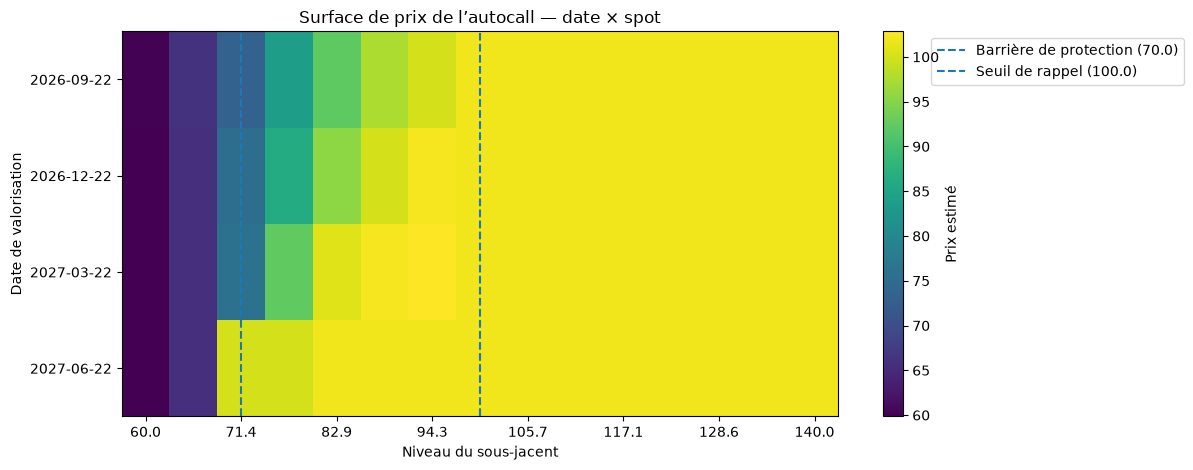

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.8))
heatmap = ax.imshow(
    price_surface_table.to_numpy(dtype=float),
    aspect="auto",
    origin="upper",
    cmap="viridis",
)

tick_step = max(1, len(spots) // 7)
x_positions = np.arange(len(spots))[::tick_step]
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{spots[index]:.1f}" for index in x_positions])
ax.set_yticks(np.arange(len(dates)))
ax.set_yticklabels([date.strftime("%Y-%m-%d") for date in dates])
ax.set_xlabel("Niveau du sous-jacent")
ax.set_ylabel("Date de valorisation")
ax.set_title("Surface de prix de l’autocall — date × spot")

reference_levels = {
    "Barrière de protection": spot0 * prod.down_barrier,
    "Seuil de rappel": spot0 * prod.autocall_strike,
}
for label, level in reference_levels.items():
    nearest_index = int(np.argmin(np.abs(spots - level)))
    ax.axvline(nearest_index, linestyle="--", linewidth=1.5, label=f"{label} ({level:.1f})")

fig.colorbar(heatmap, ax=ax, label="Prix estimé")
ax.legend(loc="upper left", bbox_to_anchor=(1.12, 1.0))
plt.tight_layout()
RUN_FIGURES["autocall_price_surface"] = fig
plt.show()


## 3. Benchmarks de réplication statique

### 3.1 Question étudiée

On cherche des poids fixes \(w_i\) tels que la valeur ou le payoff de l’autocall soit approché par un portefeuille d’options :

$$V_{\mathrm{autocall}} \approx \sum_i w_i V_i.$$

Deux familles sont comparées : **Calls + Puts** et **Full**. La première privilégie des instruments usuels ; la seconde mesure l’amélioration permise par les binaires. Les calls seuls ne sont plus affichés dans le parcours principal.


### 3.2 Benchmark sur la surface de prix

Les poids sont ajustés sur une grille date–spot, puis évalués hors des points utilisés pour l’ajustement. Le tableau principal compare l’erreur, la parcimonie et la concentration. Les poids complets et les surfaces détaillées sont des diagnostics optionnels.


In [11]:
price_benchmark_results = {}
price_benchmark_rows = []

for penalty in ["l0", "l1", "l2", "elastic_net", "l1_2"]:
    benchmark_solver = "proximal" if penalty == "l0" else SOLVER
    for family in MAIN_FAMILIES:
        result = run_naive_benchmark_price(
            product=prod,
            spot0=spot0,
            valuation_date=valuation_date,
            maturity_date=maturity_date,
            rate=rate,
            dividend_yield=dividend_yield,
            vol=vol,
            family=family,
            n_spots=15,
            n_paths=CFG["benchmark_paths"],
            penalty=penalty,
            solver=benchmark_solver,
        )
        price_benchmark_results[(family, penalty)] = result
        price_benchmark_rows.append({
            "family": FAMILY_LABELS[family],
            "penalty": penalty,
            "n_options_active": result["portfolio_metrics"]["n_options_active"],
            "test_rmse": result["metrics_test"].get("rmse", np.nan),
            "test_mae": result["metrics_test"].get("mae", np.nan),
            "max_abs_weight": result["portfolio_metrics"]["max_abs_option_weight"],
            "top_5_concentration": result["portfolio_metrics"]["top_5_option_concentration"],
        })

price_benchmark_table = pd.DataFrame(price_benchmark_rows)
display(price_benchmark_table.sort_values(["penalty", "family"]).reset_index(drop=True))

if SHOW_TECHNICAL_DETAILS:
    for (family, penalty), result in price_benchmark_results.items():
        print(f"=== {FAMILY_LABELS[family]} / {penalty} ===")
        display(result["weights"].head(20))
        display(pd.Series(result["optimization"], name="optimisation"))
        display(format_portfolio_metrics(result["portfolio_metrics"]))
        plot_benchmark_surface(
            result["dates"], result["spots"], result["target_tensor"], result["fitted_tensor"],
            title_prefix=f"[{FAMILY_LABELS[family]} / {penalty}] ",
        )


,family,penalty,n_options_active,test_rmse,test_mae,max_abs_weight,top_5_concentration
0,Calls + Puts,elastic_net,309,4.290789,2.702360,1.684662,0.265279
1,Full (avec binaires),elastic_net,612,3.999812,2.398733,1.898047,0.055662
2,Calls + Puts,l0,178,3.420559,2.102098,1.169914,0.372549
3,Full (avec binaires),l0,311,3.831690,2.269345,2.052951,0.275158
4,Calls + Puts,l1,306,15.987232,7.278235,28.707162,0.546830
5,Full (avec binaires),l1,612,3.999845,2.398785,1.898046,0.055662
6,Calls + Puts,l1_2,306,15.987249,7.278273,28.707164,0.546831
7,Full (avec binaires),l1_2,612,4.000131,2.399242,1.898033,0.055662
8,Calls + Puts,l2,306,3.541532,1.781166,1.286085,0.370233
9,Full (avec binaires),l2,612,3.624265,2.000393,1.468048,0.165507


#### Lecture visuelle : apport des binaires

Le graphique de gauche compare l’erreur hors échantillon. Celui de droite compare le nombre d’options actives. Une amélioration de `full` n’est économiquement intéressante que si la baisse d’erreur compense la complexité et la moindre liquidité introduites par les binaires.


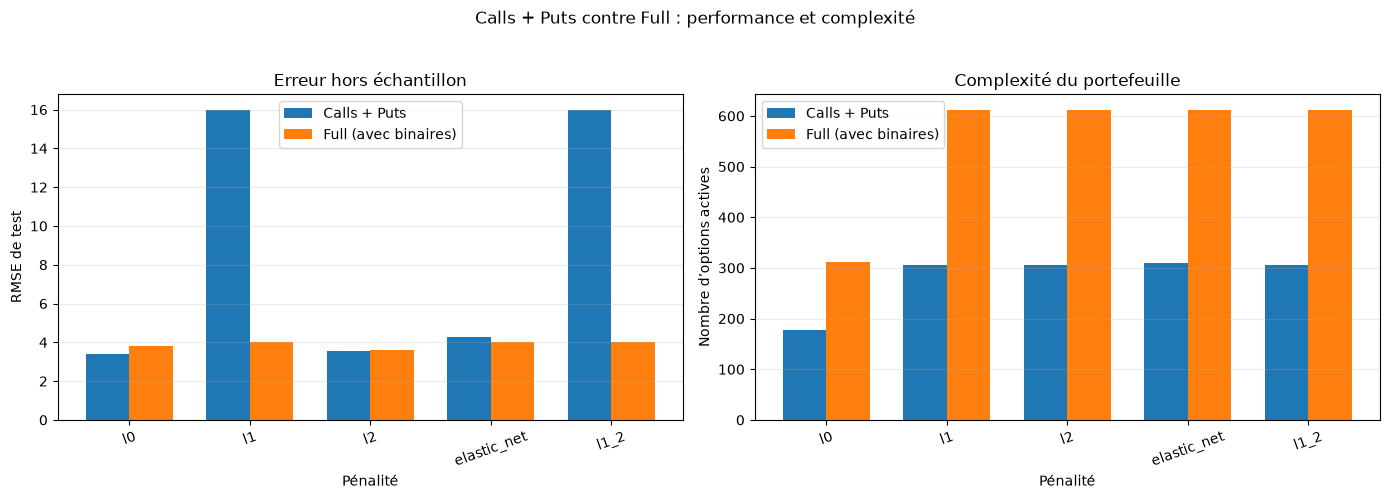

In [12]:
family_order = [FAMILY_LABELS[family] for family in MAIN_FAMILIES]
penalty_order = [
    penalty for penalty in ["l0", "l1", "l2", "elastic_net", "l1_2"]
    if penalty in set(price_benchmark_table["penalty"])
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(penalty_order), dtype=float)
width = 0.36

for family_index, family_label in enumerate(family_order):
    family_rows = (
        price_benchmark_table.loc[price_benchmark_table["family"] == family_label]
        .set_index("penalty")
        .reindex(penalty_order)
    )
    offset = (family_index - (len(family_order) - 1) / 2) * width
    axes[0].bar(x + offset, family_rows["test_rmse"], width=width, label=family_label)
    axes[1].bar(x + offset, family_rows["n_options_active"], width=width, label=family_label)

axes[0].set_title("Erreur hors échantillon")
axes[0].set_ylabel("RMSE de test")
axes[1].set_title("Complexité du portefeuille")
axes[1].set_ylabel("Nombre d’options actives")

for axis in axes:
    axis.set_xticks(x)
    axis.set_xticklabels(penalty_order, rotation=20)
    axis.set_xlabel("Pénalité")
    axis.grid(axis="y", alpha=0.25)
    axis.legend()

plt.suptitle("Calls + Puts contre Full : performance et complexité", y=1.03)
plt.tight_layout()
RUN_FIGURES["initial_replication_benchmark"] = fig
plt.show()


### 3.3 Benchmark sur l’espérance du payoff

Ici, la cible n’est plus directement le prix courant mais l’espérance risque-neutre du payoff brut. Avant maturité, on utilise la valeur Black-Scholes de chaque option puis on retire l’actualisation pour retrouver cette espérance. Un payoff évalué au spot courant ne conviendrait pas, car le spot terminal est encore inconnu.


In [13]:
from autocall_replication.replication.mean_payoff import (
    autocall_meanpayoff_on_grid_mc,
    mean_undiscounted_payoff_mc,
    run_naive_benchmark_payoff,
    vanilla_basis_expected_payoff_on_grid,
)


In [14]:
mean_payoff_results = {}
mean_payoff_rows = []

for family in MAIN_FAMILIES:
    result = run_naive_benchmark_payoff(
        product=prod,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        family=family,
        n_spots=15,
        n_paths=CFG["benchmark_paths"],
        penalty="l2",
        alpha=1e-6,
        solver=SOLVER,
    )
    mean_payoff_results[family] = result
    mean_payoff_rows.append({
        "family": FAMILY_LABELS[family],
        "train_rmse": result["metrics_train"]["rmse"],
        "test_rmse": result["metrics_test"].get("rmse", np.nan),
        "train_mae": result["metrics_train"]["mae"],
        "test_mae": result["metrics_test"].get("mae", np.nan),
        "n_options_active": result["portfolio_metrics"]["n_options_active"],
    })

mean_payoff_table = pd.DataFrame(mean_payoff_rows)
display(mean_payoff_table)

if SHOW_TECHNICAL_DETAILS:
    for family, result in mean_payoff_results.items():
        display(result["weights"].head(20))
        display(pd.Series(result["optimization"], name=f"optimisation — {FAMILY_LABELS[family]}"))
        display(format_portfolio_metrics(result["portfolio_metrics"]))
        plot_benchmark_surface(
            result["dates"], result["spots"], result["target_tensor"], result["fitted_tensor"],
            title_prefix=f"[Payoff moyen / {FAMILY_LABELS[family]}] ",
        )


,family,train_rmse,test_rmse,train_mae,test_mae,n_options_active
0,Calls + Puts,0.032119,9.308926,0.017637,4.306155,306
1,Full (avec binaires),0.000002,3.573513,0.000001,1.675908,612


### 3.4 Validation technique pathwise — alpha provisoire

Cette cellule vérifie que l’autocall et les instruments de réplication sont correctement évalués sur les mêmes trajectoires. Elle utilise provisoirement `penalty="l2"` et `alpha=1e-6`.

Le portefeuille obtenu ici n’est **pas sélectionné** et ne doit pas être interprété comme le résultat final de la réplication pathwise. La sélection économique commence dans la section 4, où plusieurs alphas sont comparés sur l’échantillon de validation.


In [15]:
from autocall_replication.monte_carlo import autocall_discounted_payoff_from_path
from autocall_replication.replication.pathwise_payoff import (
    build_pathwise_payoff_dataset,
    plot_pathwise_benchmark,
    run_naive_benchmark_payoff_pathwise,
    run_pathwise_penalty_comparison,
    run_pathwise_regularization_path,
    vanilla_discounted_payoff_from_path,
)


In [16]:
pathwise_results = {}
pathwise_rows = []

for family in MAIN_FAMILIES:
    result = run_naive_benchmark_payoff_pathwise(
        product=prod,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        family=family,
        n_paths=CFG["pathwise_paths"],
        penalty="l2",
        alpha=1e-6,
        solver=SOLVER,
    )
    pathwise_results[family] = result
    pathwise_rows.append({
        "family": FAMILY_LABELS[family],
        "train_rmse": result["metrics_train"]["rmse"],
        "test_rmse": result["metrics_test"].get("rmse", np.nan),
        "test_mae": result["metrics_test"].get("mae", np.nan),
        "n_options_active": result["portfolio_metrics"]["n_options_active"],
    })

pathwise_benchmark_table = pd.DataFrame(pathwise_rows)
display(pathwise_benchmark_table)

if SHOW_TECHNICAL_DETAILS:
    for family, result in pathwise_results.items():
        display(result["weights"].head(20))
        display(pd.Series(result["optimization"], name=f"optimisation — {FAMILY_LABELS[family]}"))
        display(format_portfolio_metrics(result["portfolio_metrics"]))
        plot_pathwise_benchmark(
            result["y"], result["replica"], title_prefix=f"[Pathwise / {FAMILY_LABELS[family]}] "
        )


,family,train_rmse,test_rmse,test_mae,n_options_active
0,Calls + Puts,1.007208,71.077814,12.685908,299
1,Full (avec binaires),0.000601,14.026787,4.086824,585


### 3.5 Cashflows dans le temps

Cette variante compare les cashflows actualisés aux dates pertinentes du contrat. Elle vérifie si une bonne réplication terminale reproduit également la chronologie des paiements. Le mode `fast` réduit le nombre de trajectoires ; les résultats finaux doivent être produits en mode `report`.


In [17]:
# ============================================================
# BENCHMARK COURBE PATHWISE : cashflows de l'autocall et du réplica le long d'une trajectoire
# ============================================================-

# ------------------------------------------------------------
# Fonction utilitaire : date réellement disponible sur le path pour une date contractuelle
# ------------------------------------------------------------
from autocall_replication.replication.static_cashflows import effective_date_on_path

# ------------------------------------------------------------
# 0) Courbe cible : cashflows actualisés de l'autocall sur un path
# ------------------------------------------------------------
from autocall_replication.replication.static_cashflows import autocall_value_curve_on_path

# ------------------------------------------------------------
# 1) Courbe réplique : cashflows actualisés du portefeuille de vanilles sur un path
# ------------------------------------------------------------
from autocall_replication.replication.static_cashflows import vanilla_portfolio_value_curve_on_path

# ------------------------------------------------------------
# 1.1) Affichage du panier retenu sur un path
# ------------------------------------------------------------

from autocall_replication.replication.static_cashflows import replication_basket_on_path

# ------------------------------------------------------------
# 2) Dataset pathwise temporel :     chaque observation = (path, date de cashflow)
#     """Construit une liste de trajectoires.
#    Pour chaque trajectoire, on stocke :
#    - le path simulé ;
#    - les cashflows actualisés de l'autocall par date ici on note y_curve ;
#    - les cashflows actualisés du réplica par date ici on note X_curve ;
#    - les dates de cashflows observées (y_curve.index)"""
# ------------------------------------------------------------

from autocall_replication.replication.static_cashflows import build_timewise_curve_dataset

# ------------------------------------------------------------
# 3) Pipeline complet : fit sur les cashflows pathwise temporels
# ------------------------------------------------------------

from autocall_replication.replication.static_cashflows import run_naive_benchmark_curve

# ------------------------------------------------------------
# 4) Plot lisible :   cashflows ponctuels et cashflows cumulés
# ------------------------------------------------------------

from autocall_replication.replication.static_cashflows import plot_timewise_curve_benchmark


In [18]:
test_path = simulate_gbm_path(
    spot0=spot0, start_date=valuation_date, end_date=maturity_date,
    rate=rate, dividend_yield=dividend_yield, vol=vol, seed=10500,
)

curve_rows = []
curve_results = {}
for penalty in ["l2", "l1", "elastic_net"]:
    for family in MAIN_FAMILIES:
        result = run_naive_benchmark_curve(
            product=prod, spot0=spot0, valuation_date=valuation_date,
            maturity_date=maturity_date, rate=rate, dividend_yield=dividend_yield,
            vol=vol, family=family, n_paths=CFG["curve_paths"],
            penalty=penalty, alpha=1e-4, solver=SOLVER,
        )
        curve_results[(family, penalty)] = result
        curve_rows.append({
            "family": FAMILY_LABELS[family], "penalty": penalty,
            "test_rmse": result["metrics_test"].get("rmse", np.nan),
            "test_mae": result["metrics_test"].get("mae", np.nan),
            "n_options_active": result["portfolio_metrics"]["n_options_active"],
        })

display(pd.DataFrame(curve_rows))

if SHOW_TECHNICAL_DETAILS:
    for (family, penalty), result in curve_results.items():
        target_curve = autocall_value_curve_on_path(
            product=prod, path=test_path, valuation_date=valuation_date,
            rate=rate, curve_dates=result["dates"],
        )
        replica_curve = vanilla_portfolio_value_curve_on_path(
            vanillas=result["vanillas"], weights=result["w"], path=test_path,
            valuation_date=valuation_date, rate=rate, curve_dates=target_curve.index,
        )
        plot_timewise_curve_benchmark(
            target_curve.index, target_curve.to_numpy(), replica_curve.to_numpy(),
            title_prefix=f"[Cashflows / {FAMILY_LABELS[family]} / {penalty}] ",
        )


,family,penalty,test_rmse,test_mae,n_options_active
0,Calls + Puts,l2,28.284711,16.710452,103
1,Full (avec binaires),l2,27.010301,13.715942,206
2,Calls + Puts,l1,28.333675,16.729349,103
3,Full (avec binaires),l1,27.069646,13.735693,206
4,Calls + Puts,elastic_net,28.332444,16.727383,103
5,Full (avec binaires),elastic_net,27.069300,13.739245,206


### 3.6 Benchmark conditionnel

Le portefeuille peut dépendre de l’état contractuel observé : produit encore vivant, date d’observation et état de la barrière. Cette approche reste semi-statique : les paniers sont définis à l’avance par état, puis appliqués lorsque cet état est atteint.


In [19]:
# Fonctions techniques du benchmark conditionnel.
# Le rechargement rend cette cellule compatible avec un noyau déjà ouvert.
import importlib
import autocall_replication.replication.semi_static as _semi_static
_semi_static = importlib.reload(_semi_static)

from autocall_replication.replication.semi_static import (
    autocall_state_curve_on_path,
    build_conditional_curve_dataset,
    build_conditional_vanilla_basis,
    conditional_features_on_path,
    conditional_portfolio_value_curve_on_path,
    predict_conditional_path_data,
    run_conditional_benchmark_curve,
)


In [20]:
conditional_rows = []
conditional_results = {}
conditional_test_path = simulate_gbm_path(
    spot0=spot0, start_date=valuation_date, end_date=maturity_date,
    rate=rate, dividend_yield=dividend_yield, vol=vol, seed=95020,
)

for penalty in ["l2", "l1", "elastic_net"]:
    for family in MAIN_FAMILIES:
        result = run_conditional_benchmark_curve(
            product=prod, spot0=spot0, valuation_date=valuation_date,
            maturity_date=maturity_date, rate=rate, dividend_yield=dividend_yield,
            vol=vol, family=family, n_paths=CFG["curve_paths"], penalty=penalty,
            alpha=1e-4, train_frac=0.7, seed=42, split_final_by_barrier=True,
            min_state_paths=20, solver=SOLVER,
        )
        conditional_results[(family, penalty)] = result
        conditional_rows.append({
            "family": FAMILY_LABELS[family], "penalty": penalty,
            "test_rmse": result["metrics_test"].get("rmse", np.nan),
            "test_mae": result["metrics_test"].get("mae", np.nan),
        })

display(pd.DataFrame(conditional_rows))

if SHOW_TECHNICAL_DETAILS:
    for (family, penalty), result in conditional_results.items():
        target_curve, replica_curve, state_curve = conditional_portfolio_value_curve_on_path(
            result=result, product=prod, path=conditional_test_path,
            valuation_date=valuation_date, rate=rate,
        )
        plot_timewise_curve_benchmark(
            target_curve.index, target_curve.to_numpy(), replica_curve.to_numpy(),
            title_prefix=f"[Conditionnel / {FAMILY_LABELS[family]} / {penalty}] ",
        )
        display(result["metrics_by_date"])
        display(format_grouped_portfolio_metrics(result["portfolio_metrics"]))


,family,penalty,test_rmse,test_mae
0,Calls + Puts,l2,10.514606,3.701471
1,Full (avec binaires),l2,0.080154,0.007754
2,Calls + Puts,l1,10.530951,3.729922
3,Full (avec binaires),l1,0.035821,0.002938
4,Calls + Puts,elastic_net,10.528949,3.728184
5,Full (avec binaires),elastic_net,0.035850,0.004297


## 4. Recherche d’alpha et sélection des profils

### 4.1 Politique conditionnelle pathwise et candidats alpha

À partir de cette section, l’étude principale devient **conditionnelle** et compare **Calls + Puts** à **Full**. Chaque panier associé à une observation est choisi au temps initial ou à l’observation précédente : l’état constaté au paiement ne peut jamais servir à choisir rétroactivement le panier qui vient d’expirer.

Un alpha global est appliqué à tous les nœuds date–état d’une même politique. Une observation statistique est une trajectoire entière et la cible est son payoff total actualisé. Le découpage est 60 % train, 20 % validation et 20 % test fermé. La sélection applique ensuite les contraintes de 2 à 100 options, le filtre de performance, le Pareto propre à chaque pénalité et la suppression des doublons.

La frontière de Pareto est calculée séparément au sein de la même pénalité : L0, L1, L2 et Elastic Net ne se dominent donc jamais entre elles. Pour cette étape, le ratio L1 d’Elastic Net reste fixé à 0,5.

La formulation L0 est pénalisée, et ne fixe donc pas arbitrairement un nombre d’instruments :

\[\min_w \; \frac{1}{2n}\lVert Aw-b\rVert_2^2 + \alpha_0\lVert w\rVert_0.\]

Le problème est non convexe. Il est résolu par gradient proximal avec seuillage dur ; les résultats doivent donc être jugés aussi sur leur stabilité multi-calibrations. Les formulations L1 pondérée et coût fixe + proportionnel sont disponibles dans le moteur mais ne sont pas encore utilisées pour sélectionner les portefeuilles tant que les coûts unitaires n’ont pas été entièrement fiabilisés.


In [21]:
from autocall_replication.replication.conditional_policy import (
    conditional_policy_cashflow_ledger,
    policy_information_audit,
    policy_profile_metrics,
    run_conditional_policy_penalty_comparison,
)

conditional_alpha_results = {}
for family in MAIN_FAMILIES:
    conditional_alpha_results[family] = run_conditional_policy_penalty_comparison(
    product=prod,
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
        family=family,
    penalties=("l0", "l1", "l2", "elastic_net"),
    elastic_net_l1_ratio=0.5,
    n_paths=CFG["alpha_paths"],
    n_alphas=25,
    min_alpha_ratio=1e-3,
    ridge_min_alpha_ratio=1e-4,
    ridge_max_alpha_ratio=1e2,
    train_fraction=0.60,
    validation_fraction=0.20,
    min_candidate_options=2,
    max_candidate_options=100,
        min_state_paths=20,
        seed=42,
    )

alpha_table = pd.concat([result["table"].assign(family=family) for family, result in conditional_alpha_results.items()], ignore_index=True)
candidate_table = pd.concat([result["candidates"].assign(family=family) for family, result in conditional_alpha_results.items()], ignore_index=True)
candidate_policy_table = pd.concat([pd.DataFrame(result["candidate_policies"]) for result in conditional_alpha_results.values()], ignore_index=True)
profile_table = pd.concat([result["profiles"] for result in conditional_alpha_results.values()], ignore_index=True)
profile_coverage = pd.concat([result["profile_coverage"].assign(family=family) for family, result in conditional_alpha_results.items()], ignore_index=True)
duplicate_report = pd.concat([result["duplicate_report"].assign(family=family) for family, result in conditional_alpha_results.items() if not result["duplicate_report"].empty], ignore_index=True) if any(not result["duplicate_report"].empty for result in conditional_alpha_results.values()) else pd.DataFrame()

print(f"Familles étudiées : {', '.join(FAMILY_LABELS[family] for family in MAIN_FAMILIES)}")
print("Statut du test final :", {family: result["test_status"] for family, result in conditional_alpha_results.items()})
print("Profils retenus — sortie principale de cette section :")
display(profile_table)
display(profile_coverage)

print("Doublons supprimés :")
if duplicate_report.empty:
    print("Aucun doublon strict ou quasi strict supprimé.")
else:
    display(duplicate_report)

if SHOW_TECHNICAL_DETAILS:
    print("Répartition de toutes les solutions par statut :")
    display(alpha_table["selection_status"].value_counts().rename("nombre"))
    print("Candidats après l'ensemble des filtres :")
    display(candidate_table)
    print("Politiques candidates réutilisables :")
    display(candidate_policy_table)
    print("Solutions non convergées conservées pour audit :")
    display(alpha_table.loc[~alpha_table["converged"]])

print("Audit chronologique — aucune information future autorisée :")
chronology_audit = pd.concat([policy_information_audit(result).assign(family=family) for family, result in conditional_alpha_results.items()], ignore_index=True)
display(chronology_audit.groupby("family")["chronology_valid"].agg(["count", "all"]))

print("Métriques lisibles des profils — erreur totale pathwise :")
display(pd.concat([policy_profile_metrics(result) for result in conditional_alpha_results.values()], ignore_index=True))

# Exemple auditable du registre de règlements pour le premier profil FULL.
if not conditional_alpha_results["full"]["profiles"].empty:
    _ledger_profile = conditional_alpha_results["full"]["profiles"].iloc[0]
    example_policy_ledger = conditional_policy_cashflow_ledger(
        conditional_alpha_results["full"],
        penalty=str(_ledger_profile["penalty"]),
        profile=str(_ledger_profile["profile"]),
        path_index=0,
    )
    display(example_policy_ledger)


Familles étudiées : Calls + Puts, Full (avec binaires)
Statut du test final : {'calls_puts': 'reserved_not_evaluated', 'full': 'reserved_not_evaluated'}
Profils retenus — sortie principale de cette section :


,family,penalty,profile,alpha,alpha_relative,l1_ratio,validation_rmse,n_options_active,compromise_score,profile_reuses_candidate,selection_reason,solution_index
0,calls_puts,l0,performance,0.006362,0.031623,NaN,4.651271,2,0.000000,True,RMSE de validation minimale,12
1,calls_puts,l0,compromise,0.006362,0.031623,NaN,4.651271,2,0.000000,True,distance normalisée minimale parmi les candida...,12
2,calls_puts,l0,parsimony,0.006362,0.031623,NaN,4.651271,2,0.000000,True,nombre d'options minimal parmi les candidats n...,12
3,calls_puts,l1,performance,0.305062,0.074989,NaN,2.628482,7,0.000000,True,RMSE de validation minimale,9
4,calls_puts,l1,compromise,0.305062,0.074989,NaN,2.628482,7,0.000000,True,distance normalisée minimale parmi les candida...,9
5,calls_puts,l1,parsimony,0.305062,0.074989,NaN,2.628482,7,0.000000,True,nombre d'options minimal parmi les candidats n...,9
6,calls_puts,l2,performance,2151.919048,56.234133,NaN,5.204499,92,1.000000,True,RMSE de validation minimale,1
7,calls_puts,l2,compromise,2151.919048,56.234133,NaN,5.204499,92,1.000000,True,distance normalisée minimale parmi les candida...,1
8,calls_puts,l2,parsimony,3826.713336,100.000000,NaN,5.210028,87,1.000000,False,nombre d'options minimal parmi les candidats n...,0
9,calls_puts,elastic_net,performance,0.813614,0.100000,0.5,2.619514,11,0.000000,True,RMSE de validation minimale,8


,penalty,n_distinct_candidates,n_profiles,status,family
0,l0,1,3,profiles_reuse_candidates,calls_puts
1,l1,1,3,profiles_reuse_candidates,calls_puts
2,l2,2,3,profiles_reuse_candidates,calls_puts
3,elastic_net,1,3,profiles_reuse_candidates,calls_puts
4,l0,2,3,profiles_reuse_candidates,full
5,l1,4,3,three_distinct_profiles,full
6,l2,0,0,no_candidate_after_filters,full
7,elastic_net,8,3,three_distinct_profiles,full


Doublons supprimés :


,penalty,duplicate_type,kept_alpha,removed_alpha,kept_n_options_active,removed_n_options_active,kept_validation_rmse,removed_validation_rmse,support_jaccard,relative_weight_distance,reason,family
0,l2,quasi_strict_duplicate,2151.919048,1210.113009,92,97,5.204499,5.194664,0.95098,0.008094,"support >= 95 %, poids proches et performance ...",calls_puts


Audit chronologique — aucune information future autorisée :


,count,all
family,,
calls_puts,627,True
full,627,True


Métriques lisibles des profils — erreur totale pathwise :


,family,penalty,profile,train_mae,train_rmse,train_max_abs_error,train_mean_error,validation_mae,validation_rmse,validation_max_abs_error,validation_mean_error,n_policy_nodes,n_unique_instruments,mean_active_options_per_visited_node,max_active_options_in_node,expected_gross_weight_per_visit,test_status
0,calls_puts,l0,performance,0.632302,2.211858,18.678235,0.000089,1.057246,4.651271,29.810157,-0.245221,7,6,0.229665,2,1.032129,reserved_not_evaluated
1,calls_puts,l0,compromise,0.632302,2.211858,18.678235,0.000089,1.057246,4.651271,29.810157,-0.245221,7,6,0.229665,2,1.032129,reserved_not_evaluated
2,calls_puts,l0,parsimony,0.632302,2.211858,18.678235,0.000089,1.057246,4.651271,29.810157,-0.245221,7,6,0.229665,2,1.032129,reserved_not_evaluated
3,calls_puts,l1,performance,0.578092,2.019375,19.078973,0.000193,0.549340,2.628482,20.025349,0.277352,7,11,0.454545,3,1.039600,reserved_not_evaluated
4,calls_puts,l1,compromise,0.578092,2.019375,19.078973,0.000193,0.549340,2.628482,20.025349,0.277352,7,11,0.454545,3,1.039600,reserved_not_evaluated
5,calls_puts,l1,parsimony,0.578092,2.019375,19.078973,0.000193,0.549340,2.628482,20.025349,0.277352,7,11,0.454545,3,1.039600,reserved_not_evaluated
6,calls_puts,l2,performance,1.647379,4.960156,29.845746,-0.003918,1.661902,5.204499,29.713340,-0.879995,7,68,12.413078,24,0.506497,reserved_not_evaluated
7,calls_puts,l2,compromise,1.647379,4.960156,29.845746,-0.003918,1.661902,5.204499,29.713340,-0.879995,7,68,12.413078,24,0.506497,reserved_not_evaluated
8,calls_puts,l2,parsimony,1.647225,4.963987,29.882408,-0.002230,1.662392,5.210028,29.758659,-0.880273,7,63,10.805423,24,0.505237,reserved_not_evaluated
9,calls_puts,elastic_net,performance,0.760674,2.359750,18.932312,-0.000250,0.554981,2.619514,19.865355,0.143292,7,14,0.961722,5,0.962597,reserved_not_evaluated


,path_index,payment_date,information_date,observed_state_at_decision,selected_node_state,alive_at_decision,target_cashflow_pv,replica_cashflow_pv,replication_surplus_pv,cash_account_before_settlement_pv,cash_account_after_settlement_pv,n_active_options_settled,recalled_at_payment,new_position_after_recall,remaining_positions_after_settlement,liquidation_value_pv,liquidation_reason
0,0,2026-09-22,NaT,initial,initial,True,101.214982,101.215519,0.000538,0.000000,0.000538,1,True,False,0,0.0,one_period_positions_expired_at_observation
1,0,2026-12-22,2026-09-22,barrier_clear,NaN,False,0.000000,0.000000,0.000000,0.000538,0.000538,0,False,False,0,0.0,not_applicable
2,0,2027-03-22,2026-12-22,barrier_clear,NaN,False,0.000000,0.000000,0.000000,0.000538,0.000538,0,False,False,0,0.0,not_applicable
3,0,2027-06-22,2027-03-22,barrier_clear,NaN,False,0.000000,0.000000,0.000000,0.000538,0.000538,0,False,False,0,0.0,not_applicable


### 4.2 Lecture des graphiques

> **Périmètre des figures de choix : L0, L1 et Elastic Net.** Ces trois pénalités peuvent annuler exactement des poids ; le nombre d’options actives mesure donc réellement la parcimonie. L0 est non convexe et fait l’objet du filtre de stabilité. L2 (Ridge) est bien calculée, mais elle réduit les poids sans généralement les annuler : la placer sur le même graphique précision–parcimonie serait trompeur. Ses diagnostics restent disponibles en mode technique.

La lecture est volontairement organisée du plus décisionnel au plus technique :

1. **Compromis précision–parcimonie** : un panneau par famille ; les points gris sont les solutions admissibles dominées et les courbes colorées les candidats non dominés. La **couleur indique la pénalité** et le **marqueur le profil retenu**.
2. **Choix d’alpha** : une ligne par pénalité parcimonieuse, avec l’erreur à gauche et le nombre d’options à droite. Ici, la **couleur indique la famille** et le **marqueur le profil retenu**.
3. **Diagnostics L2 (Ridge)** : ils sont masqués en mode normal, car Ridge réduit les poids mais ne crée généralement pas de poids exactement nuls. Ils restent accessibles avec `SHOW_TECHNICAL_DETAILS = True`.

Les légendes rappellent systématiquement ces deux conventions visuelles ; aucune étiquette n’est écrite directement sur les points afin d’éviter les chevauchements.


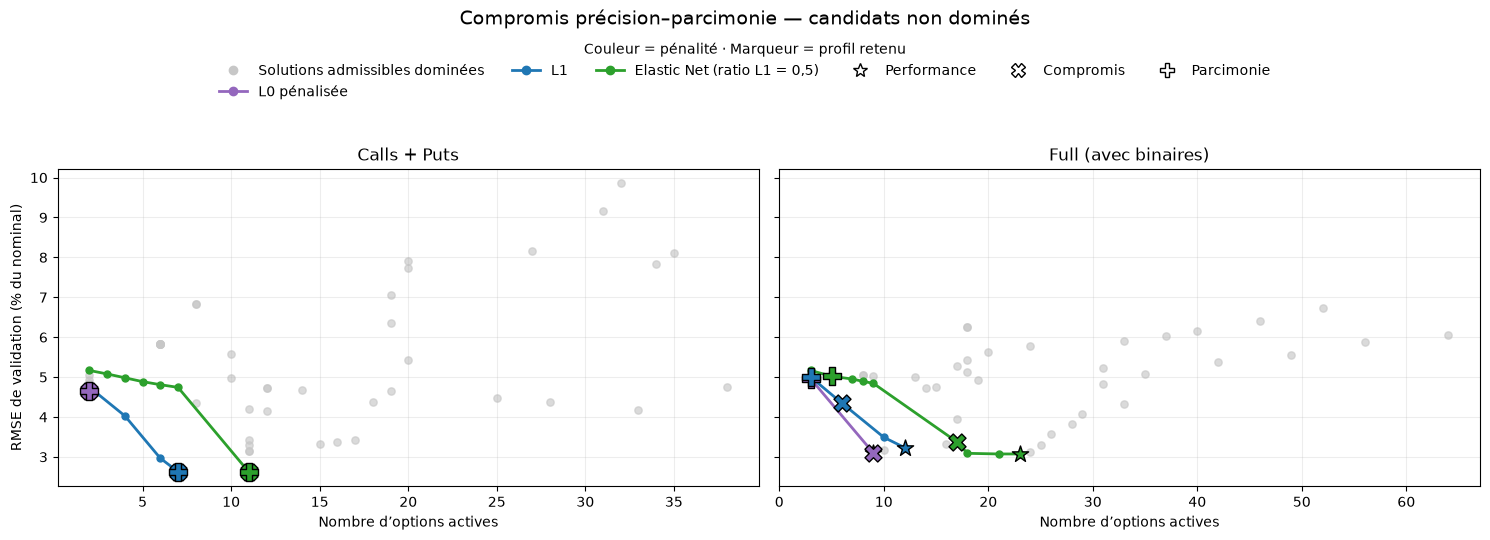

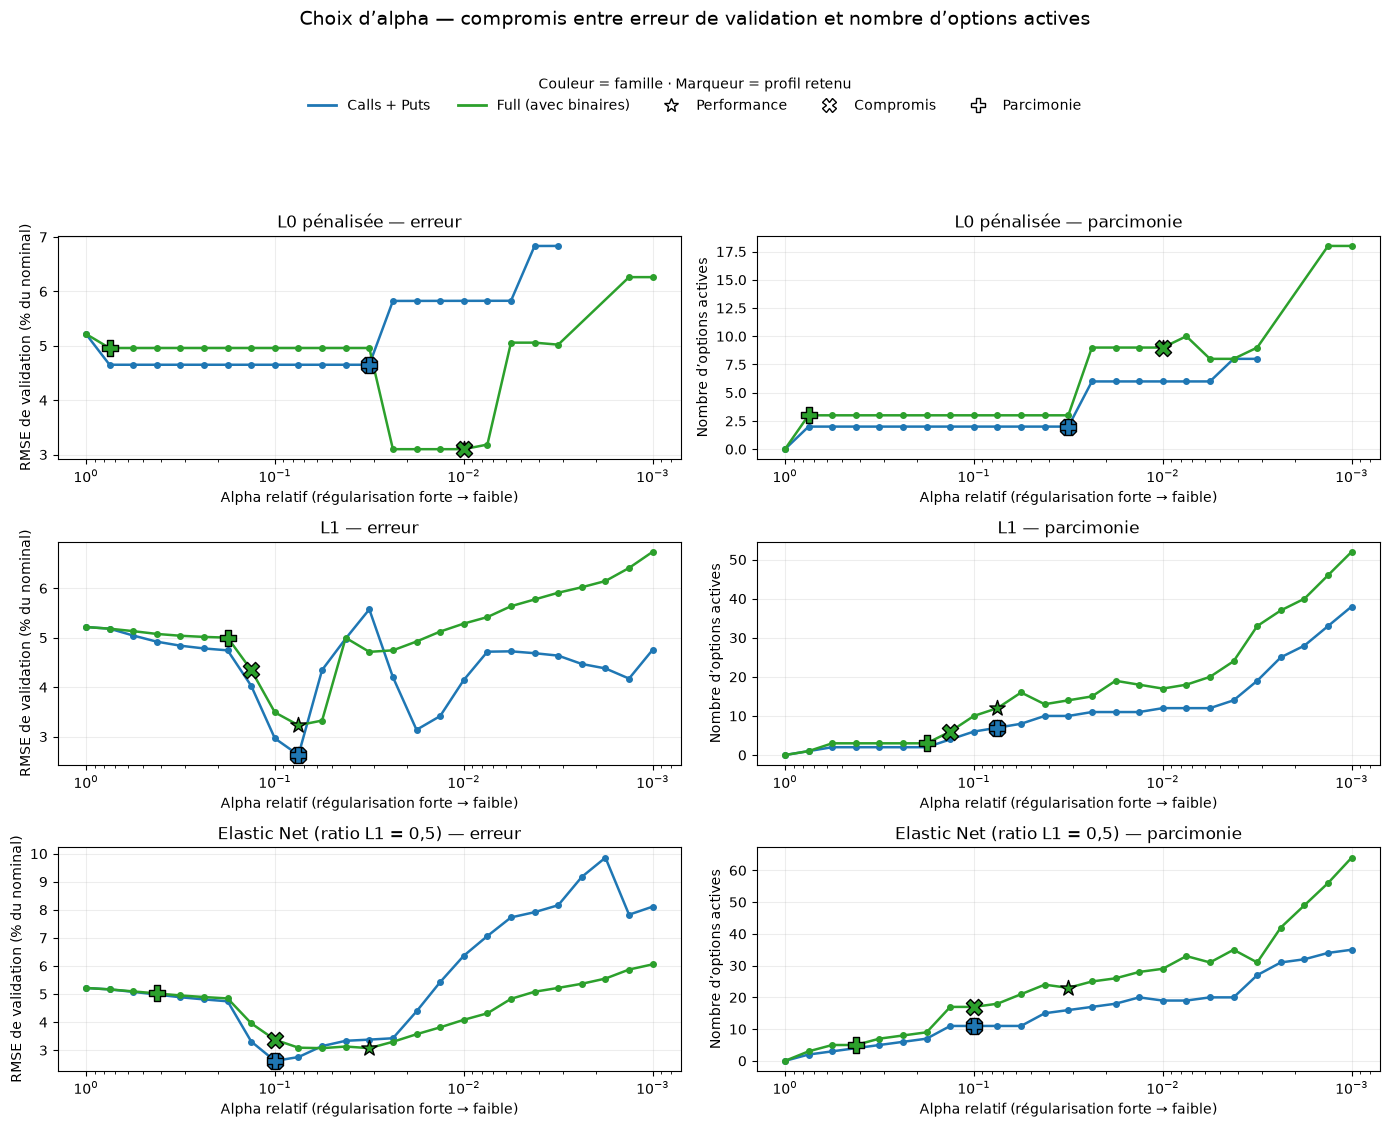

L2 (Ridge) : diagnostics détaillés affichés uniquement si SHOW_TECHNICAL_DETAILS = True.


In [22]:
# Figures de décision : calculs inchangés, présentation simplifiée.
from matplotlib.lines import Line2D

penalty_labels = {
    "l0": "L0 pénalisée",
    "l1": "L1",
    "l2": "L2 (Ridge)",
    "elastic_net": "Elastic Net (ratio L1 = 0,5)",
}
penalty_colors = {"l0": "tab:purple", "l1": "tab:blue", "l2": "tab:orange", "elastic_net": "tab:green"}
family_colors = {"calls_puts": "tab:blue", "full": "tab:green"}
sparse_penalties = ("l0", "l1", "elastic_net")
profile_markers = {"performance": "*", "compromise": "X", "parsimony": "P"}
profile_labels = {"performance": "Performance", "compromise": "Compromis", "parsimony": "Parcimonie"}
rmse_scale = 100.0 / float(prod.notional)

penalty_legend = [
    Line2D([0], [0], color=penalty_colors[name], marker="o", linewidth=2, label=penalty_labels[name])
    for name in sparse_penalties
]
dominated_legend = Line2D(
    [0], [0], linestyle="None", marker="o", markersize=6,
    markerfacecolor="0.78", markeredgecolor="0.78",
    label="Solutions admissibles dominées",
)
family_legend = [
    Line2D([0], [0], color=family_colors[name], linewidth=2, label=FAMILY_LABELS[name])
    for name in MAIN_FAMILIES
]
profile_legend = [
    Line2D(
        [0], [0], linestyle="None", marker=profile_markers[name], markersize=10,
        markerfacecolor="white", markeredgecolor="black", label=profile_labels[name],
    )
    for name in ("performance", "compromise", "parsimony")
]

# 1) Figure principale : précision contre nombre d'instruments, une famille par panneau.
fig, decision_axes = plt.subplots(1, len(MAIN_FAMILIES), figsize=(15, 5.2), sharey=True)
for axis, family in zip(decision_axes, MAIN_FAMILIES):
    family_search = alpha_table.loc[
        (alpha_table["family"] == family) & alpha_table["penalty"].isin(sparse_penalties)
    ]
    for (family_name, penalty), penalty_table in family_search.groupby(["family", "penalty"], sort=False):
        eligible = penalty_table.loc[
            penalty_table["converged"]
            & penalty_table["n_options_active"].between(2, 100)
        ]
        dominated = eligible.loc[~eligible["is_candidate_pareto"]]
        candidates = penalty_table.loc[penalty_table["is_candidate"]].sort_values("n_options_active")
        axis.scatter(
            dominated["n_options_active"], dominated["validation_rmse"] * rmse_scale,
            color="0.78", s=28, alpha=0.65, zorder=1,
        )
        axis.plot(
            candidates["n_options_active"], candidates["validation_rmse"] * rmse_scale,
            color=penalty_colors[penalty], marker="o", linewidth=2, markersize=5, zorder=3,
        )

    selected_family = profile_table.loc[
        (profile_table["family"] == family) & profile_table["penalty"].isin(sparse_penalties)
    ]
    for _, selected in selected_family.iterrows():
        profile_name = str(selected["profile"])
        axis.scatter(
            selected["n_options_active"], selected["validation_rmse"] * rmse_scale,
            marker=profile_markers.get(profile_name, "o"), s=150,
            color=penalty_colors[str(selected["penalty"])], edgecolor="black", zorder=5,
        )

    axis.set_title(FAMILY_LABELS[family])
    axis.set_xlabel("Nombre d’options actives")
    axis.grid(alpha=0.22)

decision_axes[0].set_ylabel("RMSE de validation (% du nominal)")
fig.suptitle("Compromis précision–parcimonie — candidats non dominés", y=1.03, fontsize=14)
fig.legend(
    handles=[dominated_legend] + penalty_legend + profile_legend,
    title="Couleur = pénalité · Marqueur = profil retenu",
    loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=6, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.86))
RUN_FIGURES["alpha_precision_parsimony"] = fig
plt.show()

# 2) Sensibilité à alpha : une ligne par pénalité pour éviter de superposer les messages.
fig, alpha_axes = plt.subplots(len(sparse_penalties), 2, figsize=(14, 11), squeeze=False)
for row_index, penalty in enumerate(sparse_penalties):
    for family in MAIN_FAMILIES:
        penalty_table = alpha_table.loc[
            (alpha_table["family"] == family) & (alpha_table["penalty"] == penalty)
        ]
        converged = penalty_table.loc[penalty_table["converged"]].sort_values("alpha_relative", ascending=False)
        alpha_axes[row_index, 0].plot(
            converged["alpha_relative"], converged["validation_rmse"] * rmse_scale,
            color=family_colors[family], marker="o", markersize=4, linewidth=1.8,
        )
        alpha_axes[row_index, 1].plot(
            converged["alpha_relative"], converged["n_options_active"],
            color=family_colors[family], marker="o", markersize=4, linewidth=1.8,
        )

        selected_profiles = profile_table.loc[
            (profile_table["family"] == family) & (profile_table["penalty"] == penalty)
        ]
        for _, selected in selected_profiles.iterrows():
            marker = profile_markers.get(str(selected["profile"]), "o")
            alpha_axes[row_index, 0].scatter(
                selected["alpha_relative"], selected["validation_rmse"] * rmse_scale,
                marker=marker, s=135, color=family_colors[family], edgecolor="black", zorder=5,
            )
            alpha_axes[row_index, 1].scatter(
                selected["alpha_relative"], selected["n_options_active"],
                marker=marker, s=135, color=family_colors[family], edgecolor="black", zorder=5,
            )

    for axis in alpha_axes[row_index]:
        axis.set_xscale("log")
        axis.invert_xaxis()
        axis.set_xlabel("Alpha relatif (régularisation forte → faible)")
        axis.grid(alpha=0.22)
    alpha_axes[row_index, 0].set_ylabel("RMSE de validation (% du nominal)")
    alpha_axes[row_index, 1].set_ylabel("Nombre d’options actives")
    alpha_axes[row_index, 0].set_title(f"{penalty_labels[penalty]} — erreur")
    alpha_axes[row_index, 1].set_title(f"{penalty_labels[penalty]} — parcimonie")

fig.suptitle("Choix d’alpha — compromis entre erreur de validation et nombre d’options actives", y=1.02, fontsize=14)
fig.legend(
    handles=family_legend + profile_legend,
    title="Couleur = famille · Marqueur = profil retenu",
    loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=5, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
RUN_FIGURES["alpha_sensitivity"] = fig
plt.show()

# 3) L2 réduit les poids sans créer une vraie parcimonie : diagnostics réservés au mode technique.
l2_table = alpha_table.loc[(alpha_table["penalty"] == "l2") & alpha_table["converged"]]
l2_diagnostics = [
    ("sum_abs_option_weights", "Somme absolue des quantités d’options"),
    ("max_abs_option_weight", "Plus grande quantité absolue"),
    ("top_5_option_concentration", "Part portée par les cinq principales positions"),
]
print("L2 (Ridge) : diagnostics détaillés affichés uniquement si SHOW_TECHNICAL_DETAILS = True.")

if SHOW_TECHNICAL_DETAILS:
    fig, l2_axes = plt.subplots(1, 3, figsize=(17, 4.8))
    for axis, (metric, title) in zip(l2_axes, l2_diagnostics):
        for family, family_table in l2_table.groupby("family", sort=False):
            axis.plot(
                family_table["alpha_relative"], family_table[metric],
                marker="o", markersize=4, color=family_colors[family], linewidth=1.8,
            )
        selected_l2 = profile_table.loc[profile_table["penalty"] == "l2"]
        if metric in selected_l2.columns:
            for _, selected in selected_l2.iterrows():
                axis.scatter(
                    selected["alpha_relative"], selected[metric],
                    marker=profile_markers.get(str(selected["profile"]), "o"), s=135,
                    color=family_colors[str(selected["family"])], edgecolor="black", zorder=5,
                )
        axis.set_xscale("log")
        axis.invert_xaxis()
        axis.set_xlabel("Alpha relatif (régularisation forte → faible)")
        axis.set_ylabel(title)
        axis.set_title(title)
        axis.grid(alpha=0.22)
    fig.suptitle("Diagnostics techniques L2 (Ridge)", y=1.04, fontsize=14)
    fig.legend(
        handles=family_legend + profile_legend,
        title="Couleur = famille · Marqueur = profil retenu",
        loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=5, frameon=False,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.86))
    RUN_FIGURES["ridge_diagnostics"] = fig
    plt.show()


## 5. Stabilité des portefeuilles retenus

### Objectif et règle

Un bon alpha conditionnel ne doit pas produire une politique radicalement différente lorsque l’échantillon Monte-Carlo change. Chaque profil de chaque famille est donc recalibré sur dix graines indépendantes, en conservant la topologie date–état définie par la calibration initiale.

Le tableau principal contient une ligne par profil. Le tableau brut des dix recalibrations par profil n’est affiché que lorsque `SHOW_TECHNICAL_DETAILS = True`.


In [23]:
from autocall_replication.replication.stability import (
    apply_stability_filter,
    run_conditional_policy_profile_stability,
)

conditional_stability_results = {}
stable_profile_results = {}
for family, alpha_result in conditional_alpha_results.items():
    stability_result = run_conditional_policy_profile_stability(
        base_result=alpha_result,
    product=prod,
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
    n_calibrations=CFG["stability_calibrations"],
    n_paths=CFG["stability_paths"],
    min_active_options=2,
    max_active_options=100,
    min_valid_calibrations=9,
    )
    conditional_stability_results[family] = stability_result
    stable_profile_results[family] = apply_stability_filter(alpha_result, stability_result)

stability_profiles = {
    "summary": pd.concat([result["summary"] for result in conditional_stability_results.values()], ignore_index=True),
    "details": pd.concat([result["details"] for result in conditional_stability_results.values()], ignore_index=True),
}

print("Résumé de stabilité — une ligne par profil :")
display(stability_profiles["summary"])
print("Application du filtre :")
display(pd.DataFrame([
    {"family": family, **result["stability_filter_status"]}
    for family, result in stable_profile_results.items()
]))
display(pd.concat([result["profiles"] for result in stable_profile_results.values()], ignore_index=True))

if SHOW_TECHNICAL_DETAILS:
    print("Détail des dix recalibrations par profil :")
    display(stability_profiles["details"])


Résumé de stabilité — une ligne par profil :


,family,penalty,profile,n_calibrations,n_converged,convergence_rate,n_valid_active_counts,validation_rmse_mean,validation_rmse_std,n_options_active_mean,n_options_active_std,support_jaccard_median,relative_weight_distance_mean,passes_stability_filter
0,calls_puts,l0,performance,10,10,1.0,10,3.016291,0.849108,5.6,0.843274,0.333333,0.355593,True
1,calls_puts,l0,compromise,10,10,1.0,10,3.016291,0.849108,5.6,0.843274,0.333333,0.355593,True
2,calls_puts,l0,parsimony,10,10,1.0,10,3.016291,0.849108,5.6,0.843274,0.333333,0.355593,True
3,calls_puts,l1,performance,10,10,1.0,10,3.263680,0.153215,5.3,0.483046,0.714286,0.279736,True
4,calls_puts,l1,compromise,10,10,1.0,10,3.263680,0.153215,5.3,0.483046,0.714286,0.279736,True
5,calls_puts,l1,parsimony,10,10,1.0,10,3.263680,0.153215,5.3,0.483046,0.714286,0.279736,True
6,calls_puts,l2,performance,10,10,1.0,10,5.226730,0.009789,91.3,2.213594,1.000000,0.013969,True
7,calls_puts,l2,compromise,10,10,1.0,10,5.226730,0.009789,91.3,2.213594,1.000000,0.013969,True
8,calls_puts,l2,parsimony,10,10,1.0,10,5.232325,0.009854,87.2,1.873796,0.988636,0.013958,True
9,calls_puts,elastic_net,performance,10,10,1.0,10,2.640069,0.012020,11.0,0.000000,1.000000,0.031625,True


Application du filtre :


,family,n_profiles_before,n_profiles_after,rule,test_status
0,calls_puts,12,12,convergence 10/10 et nombre d'actifs valide su...,reserved_not_evaluated
1,full,9,7,convergence 10/10 et nombre d'actifs valide su...,reserved_not_evaluated


,family,penalty,profile,alpha,alpha_relative,l1_ratio,validation_rmse,n_options_active,compromise_score,profile_reuses_candidate,selection_reason,solution_index
0,calls_puts,l0,performance,0.006362,0.031623,NaN,4.651271,2,0.000000,True,RMSE de validation minimale,12
1,calls_puts,l0,compromise,0.006362,0.031623,NaN,4.651271,2,0.000000,True,distance normalisée minimale parmi les candida...,12
2,calls_puts,l0,parsimony,0.006362,0.031623,NaN,4.651271,2,0.000000,True,nombre d'options minimal parmi les candidats n...,12
3,calls_puts,l1,performance,0.305062,0.074989,NaN,2.628482,7,0.000000,True,RMSE de validation minimale,9
4,calls_puts,l1,compromise,0.305062,0.074989,NaN,2.628482,7,0.000000,True,distance normalisée minimale parmi les candida...,9
5,calls_puts,l1,parsimony,0.305062,0.074989,NaN,2.628482,7,0.000000,True,nombre d'options minimal parmi les candidats n...,9
6,calls_puts,l2,performance,2151.919048,56.234133,NaN,5.204499,92,1.000000,True,RMSE de validation minimale,1
7,calls_puts,l2,compromise,2151.919048,56.234133,NaN,5.204499,92,1.000000,True,distance normalisée minimale parmi les candida...,1
8,calls_puts,l2,parsimony,3826.713336,100.000000,NaN,5.210028,87,1.000000,False,nombre d'options minimal parmi les candidats n...,0
9,calls_puts,elastic_net,performance,0.813614,0.100000,0.5,2.619514,11,0.000000,True,RMSE de validation minimale,8


## 6. Risque terminal de la politique conditionnelle

### 6.1 Niveaux 1 et 2 : dette brute et exposition résiduelle de réplication

Tous les flux sont actualisés à la date de valorisation. Le point de vue retenu est celui de l’émetteur :

$$L_{\mathrm{brut}} = H_0 - V_0,$$

$$E_{\mathrm{réplication}} = H_0 - R_0.$$

- $H_0$ est le payoff actualisé de l’autocall sur une trajectoire ;
- $V_0$ est sa valeur de modèle, estimée sur l’échantillon indépendant ;
- $R_0$ est le payoff actualisé de la politique conditionnelle pathwise ;
- une erreur positive signifie que la politique conditionnelle est insuffisante pour payer la dette.

Les résultats sont exprimés en montant, pourcentage et points de base du nominal. Les réductions relatives ne sont calculées que lorsque le risque brut est strictement positif. Les fréquences conditionnelles et une alerte sur les faibles effectifs accompagnent les quantiles.

Le test final réservé pour la sélection d’alpha reste fermé.


In [24]:
# Recharge le module pour rendre la cellule compatible avec un noyau déjà ouvert.
import importlib
import autocall_replication.replication.risk as _risk_module
_risk_module = importlib.reload(_risk_module)

from autocall_replication.replication.risk import (
    compare_transaction_cost_to_risk_reduction,
    evaluate_conditional_policy_profile_risk,
)

conditional_risk_results = {}
for family, stable_result in stable_profile_results.items():
    if stable_result["profiles"].empty:
        print(f"{FAMILY_LABELS[family]} : aucun profil stable, risque non calculé.")
        continue
    conditional_risk_results[family] = evaluate_conditional_policy_profile_risk(
        base_result=stable_result,
        product=prod,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        n_paths=CFG["risk_paths"],
        seed=10500,
        min_condition_observations=200,
    )

risk_result = None if not conditional_risk_results else {
    "comparison": pd.concat([result["comparison"] for result in conditional_risk_results.values()], ignore_index=True),
    "conditional_comparison": pd.concat([result["conditional_comparison"] for result in conditional_risk_results.values()], ignore_index=True),
    "risk_summary": pd.concat([result["risk_summary"] for result in conditional_risk_results.values()], ignore_index=True),
}

if risk_result is not None:

    print("Niveau calculé : 2 — exposition résiduelle après réplication statique")
    display(pd.Series({
        "convention de valeur": "actualisée à la date de valorisation",
        "convention de perte": "autocall moins politique conditionnelle",
        "chronologie": "état précédent vers portefeuille suivant",
        "couverture dynamique": "niveau 3 non implémenté",
        "test final": "réservé et non évalué",
        "trajectoires indépendantes par famille": CFG["risk_paths"],
    }, name="méthodologie"))

    print("Effectif et fréquence des régimes contractuels, par famille :")
    display(pd.concat([result["condition_summary"].assign(family=family) for family, result in conditional_risk_results.items()], ignore_index=True))

    risk_display_columns = [
        "family", "penalty", "profile",
        "mean_replication_error", "mean_replication_error_pct_notional",
        "rmse_relative_reduction", "es_975_relative_reduction",
        "residual_rmse_pct_notional", "residual_rmse_bps_notional",
        "residual_es_975_pct_notional", "residual_es_975_bps_notional",
        "under_replication_rate",
    ]
    print("Synthèse globale de l’exposition résiduelle :")
    display(risk_result["risk_summary"][risk_display_columns])

    conditional_columns = [
        "family", "penalty", "profile", "condition", "n_observations",
        "condition_frequency", "quantile_reliability",
        "rmse_relative_reduction", "es_975_relative_reduction",
    ]
    print("Réductions relatives par régime contractuel :")
    display(risk_result["conditional_comparison"][conditional_columns])

    if SHOW_TECHNICAL_DETAILS:
        print("Risque brut complet :")
        display(pd.concat([result["gross_risk"].assign(family=family) for family, result in conditional_risk_results.items()], ignore_index=True))
        print("Exposition résiduelle complète :")
        display(pd.concat([result["residual_risk"] for result in conditional_risk_results.values()], ignore_index=True))
        print("Conversions longues en montant, % et bps :")
        display(pd.concat([result["gross_risk_units"].assign(family=family) for family, result in conditional_risk_results.items()], ignore_index=True))
        display(pd.concat([result["residual_risk_units"] for result in conditional_risk_results.values()], ignore_index=True))


Niveau calculé : 2 — exposition résiduelle après réplication statique


convention de valeur                          actualisée à la date de valorisation
convention de perte                        autocall moins politique conditionnelle
chronologie                               état précédent vers portefeuille suivant
couverture dynamique                                       niveau 3 non implémenté
test final                                                   réservé et non évalué
trajectoires indépendantes par famille                                        2000
Name: méthodologie, dtype: object

Effectif et fréquence des régimes contractuels, par famille :


,condition,n_observations,condition_frequency,quantile_reliability,family
0,all,2000,1.0000,sufficient,calls_puts
1,recalled,1463,0.7315,sufficient,calls_puts
2,maturity,537,0.2685,sufficient,calls_puts
3,barrier_hit,128,0.0640,warning_low_observation_count,calls_puts
4,all,2000,1.0000,sufficient,full
5,recalled,1463,0.7315,sufficient,full
6,maturity,537,0.2685,sufficient,full
7,barrier_hit,128,0.0640,warning_low_observation_count,full


Synthèse globale de l’exposition résiduelle :


,family,penalty,profile,mean_replication_error,mean_replication_error_pct_notional,rmse_relative_reduction,es_975_relative_reduction,residual_rmse_pct_notional,residual_rmse_bps_notional,residual_es_975_pct_notional,residual_es_975_bps_notional,under_replication_rate
0,calls_puts,l0,performance,0.412386,0.412386,0.517794,-3.182470,3.709649,370.964946,18.368552,1836.855210,0.3645
1,calls_puts,l0,compromise,0.412386,0.412386,0.517794,-3.182470,3.709649,370.964946,18.368552,1836.855210,0.3645
2,calls_puts,l0,parsimony,0.412386,0.412386,0.517794,-3.182470,3.709649,370.964946,18.368552,1836.855210,0.3645
3,calls_puts,l1,performance,0.308391,0.308391,0.616133,-2.102047,2.953123,295.312270,13.623559,1362.355872,0.4225
4,calls_puts,l1,compromise,0.308391,0.308391,0.616133,-2.102047,2.953123,295.312270,13.623559,1362.355872,0.4225
5,calls_puts,l1,parsimony,0.308391,0.308391,0.616133,-2.102047,2.953123,295.312270,13.623559,1362.355872,0.4225
6,calls_puts,l2,performance,0.137630,0.137630,0.241954,-0.947313,5.831716,583.171620,8.552201,855.220140,0.2630
7,calls_puts,l2,compromise,0.137630,0.137630,0.241954,-0.947313,5.831716,583.171620,8.552201,855.220140,0.2630
8,calls_puts,l2,parsimony,0.135626,0.135626,0.241091,-0.946639,5.838350,583.835046,8.549242,854.924172,0.2630
9,calls_puts,elastic_net,performance,0.227741,0.227741,0.660180,-1.281783,2.614266,261.426622,10.021125,1002.112487,0.3750


Réductions relatives par régime contractuel :


,family,penalty,profile,condition,n_observations,condition_frequency,quantile_reliability,rmse_relative_reduction,es_975_relative_reduction
0,calls_puts,l0,performance,all,2000.0,1.0000,sufficient,0.517794,-3.182470
1,calls_puts,l0,performance,recalled,1463.0,0.7315,sufficient,0.901468,0.890282
2,calls_puts,l0,performance,maturity,537.0,0.2685,sufficient,0.509181,-4.977036
3,calls_puts,l0,performance,barrier_hit,128.0,0.0640,warning_low_observation_count,0.556980,-45.535123
4,calls_puts,l0,compromise,all,2000.0,1.0000,sufficient,0.517794,-3.182470
...,...,...,...,...,...,...,...,...,...
71,full,elastic_net,compromise,barrier_hit,128.0,0.0640,warning_low_observation_count,0.698423,-23.888510
72,full,elastic_net,parsimony,all,2000.0,1.0000,sufficient,0.460881,-1.138539
73,full,elastic_net,parsimony,recalled,1463.0,0.7315,sufficient,0.581986,0.301727
74,full,elastic_net,parsimony,maturity,537.0,0.2685,sufficient,0.456852,-3.014094


### 6.2 Lecture visuelle de l’exposition résiduelle

Cette section présente deux lectures complémentaires, dans cet ordre :

1. **Erreur globale — réduction de la RMSE** : une valeur positive indique que la réplication réduit l’erreur moyenne.
2. **Risque extrême — multiplicateur de l’ES** : le ratio $ES_{résiduel}/ES_{brut}$ vaut `1` sans amélioration, moins de `1` en cas d’amélioration et plus de `1` en cas d’aggravation.
3. **Contrôle — montants absolus** : le graphique en barres conserve les niveaux du risque brut et de l’exposition résiduelle pour un nominal de 100.

Les deux indicateurs principaux sont calculés par :

$$100\times\left(1-\frac{RMSE_{résiduelle}}{RMSE_{brute}}\right),\qquad \frac{ES_{résiduel}}{ES_{brut}}.$$

Les deux métriques sont volontairement séparées car elles n’ont ni la même échelle ni la même interprétation. Pour Full/L2, l’absence est explicitée : aucun portefeuille Ridge/Full ne passe les filtres sous la limite de 100 options actives.

**Conclusion à retenir : la réplication réduit l’erreur globale, mais le panier statique peut encore amplifier le risque de queue.** La RMSE décrit l’erreur globale. L’Expected Shortfall 97,5 % se concentre sur la queue droite de `autocall − réplication`, c’est-à-dire les scénarios de sous-réplication les plus défavorables à l’émetteur.


Conclusion : la réplication réduit l’erreur globale, mais le panier statique peut encore amplifier le risque de queue.


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


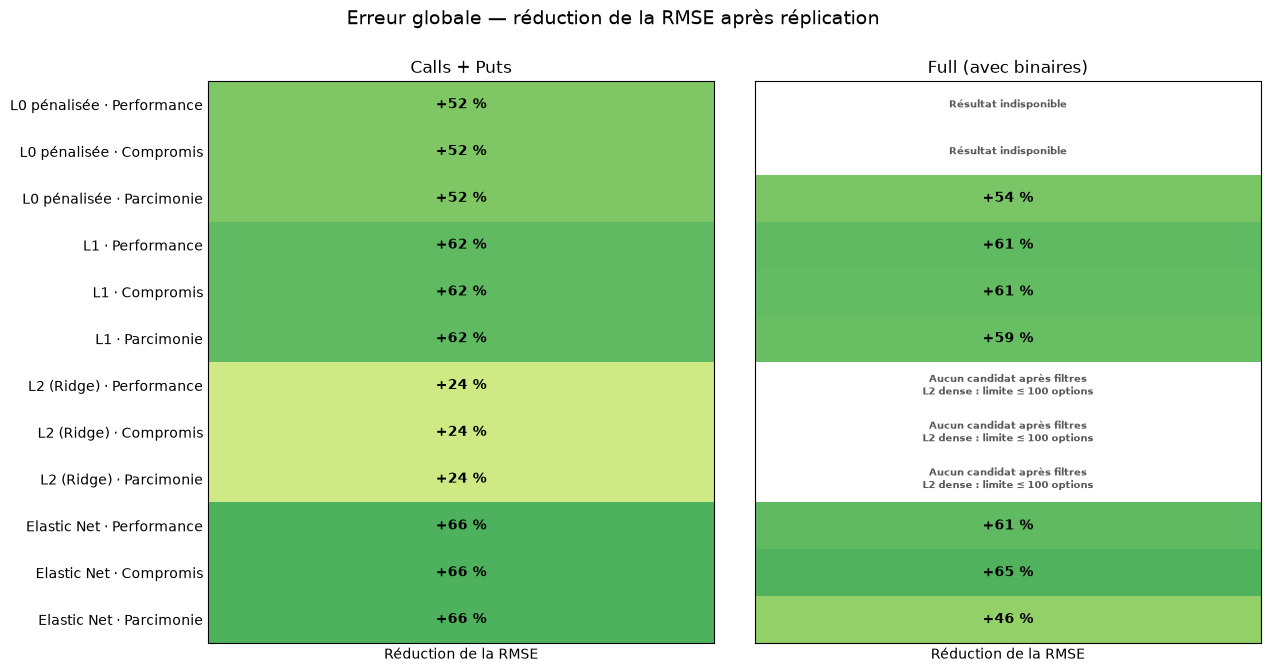

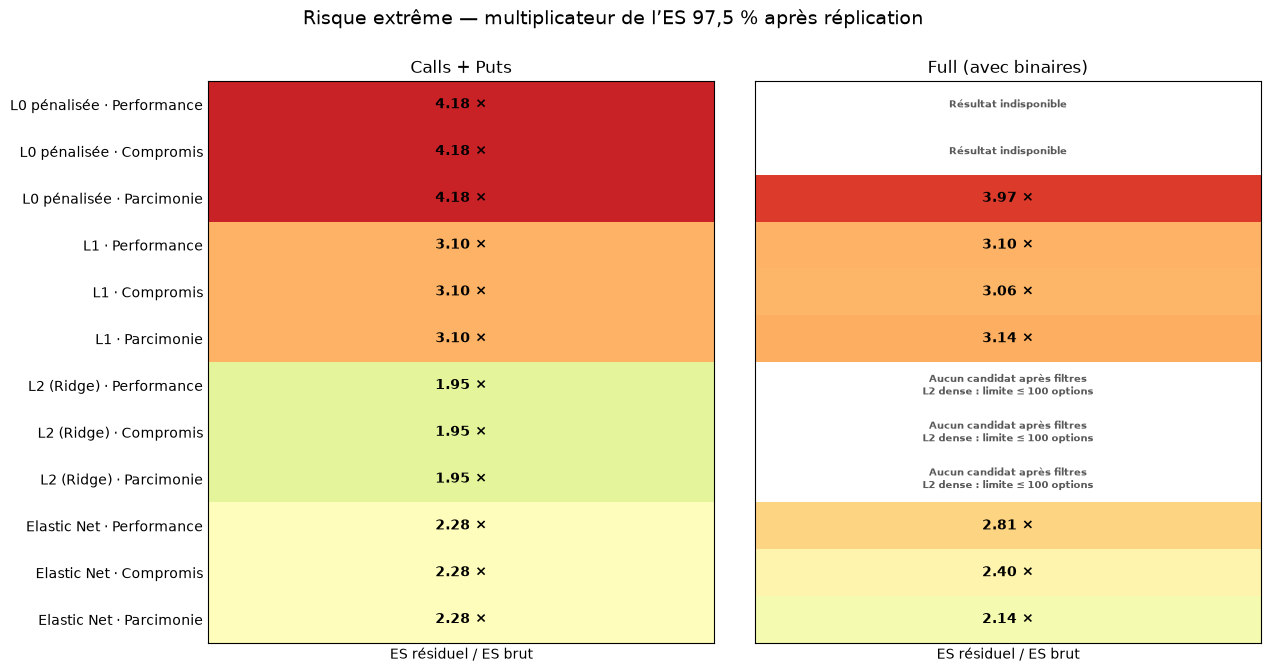

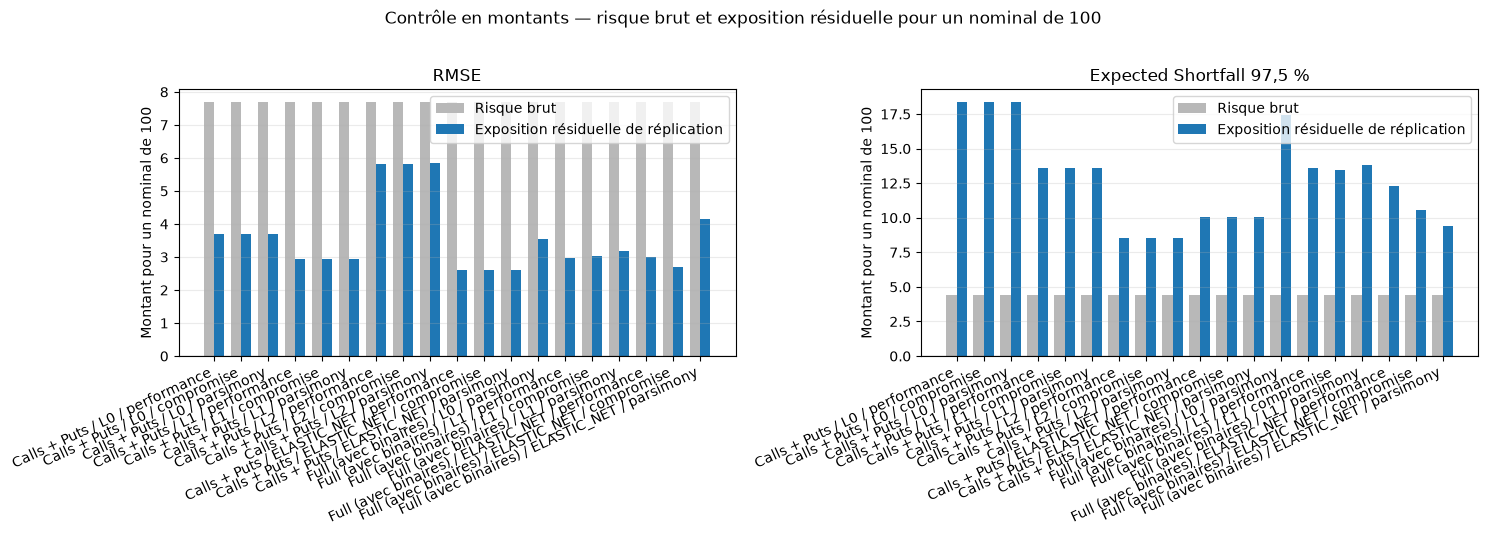

In [25]:
if risk_result is None or risk_result["comparison"].empty:
    print("Graphique de risque indisponible : aucun profil stable évalué.")
else:
    risk_plot_table = risk_result["comparison"].copy()
    risk_plot_table["candidate"] = (
        risk_plot_table["family"].map(FAMILY_LABELS) + " / " + risk_plot_table["penalty"].str.upper() + " / " + risk_plot_table["profile"]
    )

    # Vue principale : efficacité relative de chaque politique.
    risk_penalty_order = ("l0", "l1", "l2", "elastic_net")
    risk_profile_order = ("performance", "compromise", "parsimony")
    risk_method_names = {"l0": "L0 pénalisée", "l1": "L1", "l2": "L2 (Ridge)", "elastic_net": "Elastic Net"}
    risk_profile_labels = {"performance": "Performance", "compromise": "Compromis", "parsimony": "Parcimonie"}
    heatmap_index = pd.MultiIndex.from_product(
        [risk_penalty_order, risk_profile_order], names=["penalty", "profile"]
    )
    heatmap_row_labels = [
        f"{risk_method_names[penalty]} · {risk_profile_labels[profile]}"
        for penalty, profile in heatmap_index
    ]
    def missing_risk_label(family, penalty):
        if family == "full" and penalty == "l2":
            return "Aucun candidat après filtres\nL2 dense : limite ≤ 100 options"
        return "Résultat indisponible"

    def plot_risk_matrix(column, *, title, subtitle, value_format, cmap, vmin, vmax, export_name):
        fig, matrix_axes = plt.subplots(1, len(MAIN_FAMILIES), figsize=(13.5, 7.2), sharey=True)
        matrix_axes = np.atleast_1d(matrix_axes)
        for axis, family in zip(matrix_axes, MAIN_FAMILIES):
            family_table = (
                risk_plot_table.loc[risk_plot_table["family"] == family]
                .set_index(["penalty", "profile"])
                .reindex(heatmap_index)
            )
            values = family_table[[column]].to_numpy(dtype=float)
            axis.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest")
            axis.set_title(FAMILY_LABELS[family])
            axis.set_xticks([0])
            axis.set_xticklabels([subtitle])
            axis.set_yticks(np.arange(len(heatmap_row_labels)))
            axis.set_yticklabels(heatmap_row_labels)
            axis.tick_params(axis="both", length=0)
            for row_index, (penalty, _) in enumerate(heatmap_index):
                value = values[row_index, 0]
                if np.isfinite(value):
                    label = value_format(value)
                    text_color = "black"
                    font_size = 10
                else:
                    label = missing_risk_label(family, penalty)
                    text_color = "0.35"
                    font_size = 7.5
                axis.text(0, row_index, label, ha="center", va="center", color=text_color, fontsize=font_size, fontweight="semibold")
        fig.suptitle(title, y=0.98, fontsize=14)
        fig.subplots_adjust(left=0.20, right=0.98, top=0.88, bottom=0.10, wspace=0.08)
        RUN_FIGURES[export_name] = fig
        plt.show()

    print("Conclusion : la réplication réduit l’erreur globale, mais le panier statique peut encore amplifier le risque de queue.")
    risk_plot_table["rmse_reduction_pct"] = 100.0 * risk_plot_table["rmse_relative_reduction"]
    plot_risk_matrix(
        "rmse_reduction_pct",
        title="Erreur globale — réduction de la RMSE après réplication",
        subtitle="Réduction de la RMSE", value_format=lambda value: f"{value:+.0f} %",
        cmap="RdYlGn", vmin=-100.0, vmax=100.0, export_name="risk_rmse_reduction",
    )

    risk_plot_table["es_975_residual_to_gross"] = 1.0 - risk_plot_table["es_975_relative_reduction"]
    finite_es_ratios = risk_plot_table["es_975_residual_to_gross"].replace([np.inf, -np.inf], np.nan).dropna()
    es_ratio_limit = max(2.0, float(np.ceil(finite_es_ratios.max() * 2.0) / 2.0))
    plot_risk_matrix(
        "es_975_residual_to_gross",
        title="Risque extrême — multiplicateur de l’ES 97,5 % après réplication",
        subtitle="ES résiduel / ES brut", value_format=lambda value: f"{value:.2f} ×",
        cmap="RdYlGn_r", vmin=0.0, vmax=es_ratio_limit, export_name="risk_es_multiplier",
    )

    # Vue de contrôle : mêmes résultats exprimés en montants absolus.
    x = np.arange(len(risk_plot_table), dtype=float)
    width = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharex=True)
    metric_pairs = [
        ("gross_rmse", "residual_rmse", "RMSE"),
        ("gross_es_975", "residual_es_975", "Expected Shortfall 97,5 %"),
    ]
    for axis, (gross_column, residual_column, title) in zip(axes, metric_pairs):
        axis.bar(x - width / 2, risk_plot_table[gross_column], width, label="Risque brut", color="0.72")
        axis.bar(x + width / 2, risk_plot_table[residual_column], width, label="Exposition résiduelle de réplication", color="tab:blue")
        axis.axhline(0.0, color="black", linewidth=0.8)
        axis.set_title(title)
        axis.set_xticks(x)
        axis.set_xticklabels(risk_plot_table["candidate"], rotation=25, ha="right")
        axis.set_ylabel("Montant pour un nominal de 100")
        axis.grid(axis="y", alpha=0.25)
        axis.legend()

    plt.suptitle("Contrôle en montants — risque brut et exposition résiduelle pour un nominal de 100", y=1.02)
    plt.tight_layout()
    RUN_FIGURES["risk_absolute_control"] = fig
    plt.show()


### 6.3 Importance sampling — comparaison avec le Monte-Carlo standard

#### Objectif et séparation stricte des deux sortes de poids

Cette étape **ne recalcule ni alpha ni le portefeuille**. Les quantités financières $w_j$ ont déjà été estimées sur les blocs train/validation, sélectionnées, puis filtrées par stabilité. Elles sont figées avant toute mesure de risque :

$$R_i=\sum_j w_jX_{i,j},\qquad L_i=H_i-R_i.$$

Deux moteurs évaluent ensuite exactement les mêmes politiques :

1. **Monte-Carlo standard** : les trajectoires suivent directement le GBM cible et ont le même poids statistique ;
2. **importance sampling** : davantage de trajectoires baissières sont simulées, puis chaque trajectoire reçoit un poids de vraisemblance $\omega_i=p(X_i)/q(X_i)$.

> **À ne pas confondre :** $w_j$ est une quantité de call, put, binaire ou cash détenue dans le portefeuille ; $\omega_i$ est seulement le poids statistique d’une trajectoire dans une moyenne, une VaR ou un ES. L’importance sampling ne change donc aucun instrument détenu dans cette section.

L’estimateur pondéré d’une espérance est :

$$\widehat{\mathbb E}[f(X)]=\frac{\sum_i\omega_i f(X_i)}{\sum_i\omega_i}.$$

L’Expected Shortfall pondéré est :

$$\widehat{ES}_q=\frac{\sum_i\omega_iL_i\mathbf 1_{\{L_i\geq\widehat{VaR}_q\}}}{\sum_i\omega_i\mathbf 1_{\{L_i\geq\widehat{VaR}_q\}}}.$$

#### Distribution d’importance utilisée

La proposition est un mélange explicite de trois lois : 50 % de trajectoires standards, 30 % avec une inclinaison terminale de $-1$ écart-type et 20 % avec une inclinaison de $-2$ écarts-types. La composante standard évite d’abandonner les scénarios ordinaires. Les poids corrigent exactement cette surreprésentation : la mesure cible reste le GBM risque-neutre utilisé par le reste du notebook.

#### Critère de succès

L’IS n’est pas censé produire artificiellement un ES plus faible. À budget de trajectoires identique, les deux estimations doivent être compatibles ; l’intérêt de l’IS est un intervalle de confiance plus étroit et davantage d’information dans la queue. L’Effective Sample Size

$$ESS=\frac{(\sum_i\omega_i)^2}{\sum_i\omega_i^2}$$

mesure la qualité des poids. Un ESS très faible signale une déformation mal calibrée. Les résultats IS restent expérimentaux tant que la compatibilité avec le Monte-Carlo standard, les intervalles de confiance et la stabilité entre graines ne sont pas établis.


Statut méthodologique : mêmes poids financiers, deux estimateurs de risque indépendants.


poids financiers                       figés avant les deux évaluations
calibration par importance sampling                                 non
trajectoires par méthode et famille                                2000
déformations terminales                               (0.0, -1.0, -2.0)
probabilités du mélange                                 (0.5, 0.3, 0.2)
mesure cible                                 GBM risque-neutre inchangé
Name: comparaison MC / IS, dtype: object

Diagnostic des poids statistiques :


,family,n_paths,weight_mean,weight_min,weight_max,weight_cv,effective_sample_size,effective_sample_ratio
0,Calls + Puts,2000,1.022029,0.001013,1.98002,0.54641,1540.340454,0.77017
1,Full (avec binaires),2000,1.022029,0.001013,1.98002,0.54641,1540.340454,0.77017


,component,tilt,configured_probability,simulated_count,simulated_frequency,weighted_target_mass,family
0,0,0.0,0.5,1009,0.5045,0.654413,Calls + Puts
1,1,-1.0,0.3,613,0.3065,0.262399,Calls + Puts
2,2,-2.0,0.2,378,0.1890,0.083188,Calls + Puts
3,0,0.0,0.5,1009,0.5045,0.654413,Full (avec binaires)
4,1,-1.0,0.3,613,0.3065,0.262399,Full (avec binaires)
5,2,-2.0,0.2,378,0.1890,0.083188,Full (avec binaires)


...

,family,penalty,profile,standard_residual_rmse,importance_residual_rmse,standard_residual_es_95,importance_residual_es_95,standard_residual_es_975,importance_residual_es_975,standard_residual_es_99,importance_residual_es_99
0,calls_puts,elastic_net,compromise,2.614266,2.578967,6.730838,7.078356,10.021125,10.461724,13.521724,13.764874
1,calls_puts,elastic_net,parsimony,2.614266,2.578967,6.730838,7.078356,10.021125,10.461724,13.521724,13.764874
2,calls_puts,elastic_net,performance,2.614266,2.578967,6.730838,7.078356,10.021125,10.461724,13.521724,13.764874
3,calls_puts,l0,compromise,3.709649,3.479117,12.077766,11.493965,18.368552,17.436765,24.367938,23.408999
4,calls_puts,l0,parsimony,3.709649,3.479117,12.077766,11.493965,18.368552,17.436765,24.367938,23.408999
5,calls_puts,l0,performance,3.709649,3.479117,12.077766,11.493965,18.368552,17.436765,24.367938,23.408999
6,calls_puts,l1,compromise,2.953123,2.733266,8.626065,8.049912,13.623559,12.450438,19.193376,18.151355
7,calls_puts,l1,parsimony,2.953123,2.733266,8.626065,8.049912,13.623559,12.450438,19.193376,18.151355
8,calls_puts,l1,performance,2.953123,2.733266,8.626065,8.049912,13.623559,12.450438,19.193376,18.151355
9,calls_puts,l2,compromise,5.831716,5.311417,6.543655,7.119477,8.552201,9.697852,14.412444,16.724264


Expected Shortfall 97,5 % et intervalles de confiance bootstrap :


,family,penalty,profile,standard_es_975_pct_notional,standard_ci_low,standard_ci_high,importance_es_975_pct_notional,importance_ci_low,importance_ci_high,confidence_intervals_overlap,is_minus_mc_pct_notional,standard_ci_width,importance_ci_width,ci_width_change
0,calls_puts,l0,performance,18.368552,15.598677,20.242953,17.436765,15.709325,19.214588,True,-0.931787,4.644276,3.505263,-1.139013
1,calls_puts,l0,compromise,18.368552,15.584375,20.919936,17.436765,14.922781,18.978030,True,-0.931787,5.335561,4.055249,-1.280313
2,calls_puts,l0,parsimony,18.368552,15.416334,20.855913,17.436765,15.465128,19.431471,True,-0.931787,5.439579,3.966343,-1.473236
3,calls_puts,l1,performance,13.623559,10.340355,16.247371,12.450438,11.252824,13.831558,True,-1.173121,5.907017,2.578734,-3.328283
4,calls_puts,l1,compromise,13.623559,10.753274,16.054031,12.450438,11.444550,13.632406,True,-1.173121,5.300757,2.187855,-3.112901
5,calls_puts,l1,parsimony,13.623559,10.886532,15.791405,12.450438,10.985906,13.504779,True,-1.173121,4.904873,2.518873,-2.386000
6,calls_puts,l2,performance,8.552201,6.814825,11.070473,9.697852,7.343303,11.700029,True,1.145651,4.255648,4.356726,0.101077
7,calls_puts,l2,compromise,8.552201,6.287412,11.330000,9.697852,7.479436,12.154596,True,1.145651,5.042587,4.675159,-0.367428
8,calls_puts,l2,parsimony,8.549242,6.590241,10.692889,9.694745,7.661374,11.493475,True,1.145503,4.102647,3.832100,-0.270547
9,calls_puts,elastic_net,performance,10.021125,8.491758,11.082102,10.461724,9.241457,11.438967,True,0.440599,2.590344,2.197510,-0.392833


Lecture condensée — écart d’estimation et largeur des intervalles :


,Famille,Pénalité,Profil,Écart IS − MC (point de nominal),Largeur IC Monte-Carlo,Largeur IC importance sampling,Variation de largeur (IS − MC),Intervalles compatibles
0,calls_puts,l0,performance,-0.931787,4.644276,3.505263,-1.139013,True
1,calls_puts,l0,compromise,-0.931787,5.335561,4.055249,-1.280313,True
2,calls_puts,l0,parsimony,-0.931787,5.439579,3.966343,-1.473236,True
3,calls_puts,l1,performance,-1.173121,5.907017,2.578734,-3.328283,True
4,calls_puts,l1,compromise,-1.173121,5.300757,2.187855,-3.112901,True
5,calls_puts,l1,parsimony,-1.173121,4.904873,2.518873,-2.386000,True
6,calls_puts,l2,performance,1.145651,4.255648,4.356726,0.101077,True
7,calls_puts,l2,compromise,1.145651,5.042587,4.675159,-0.367428,True
8,calls_puts,l2,parsimony,1.145503,4.102647,3.832100,-0.270547,True
9,calls_puts,elastic_net,performance,0.440599,2.590344,2.197510,-0.392833,True


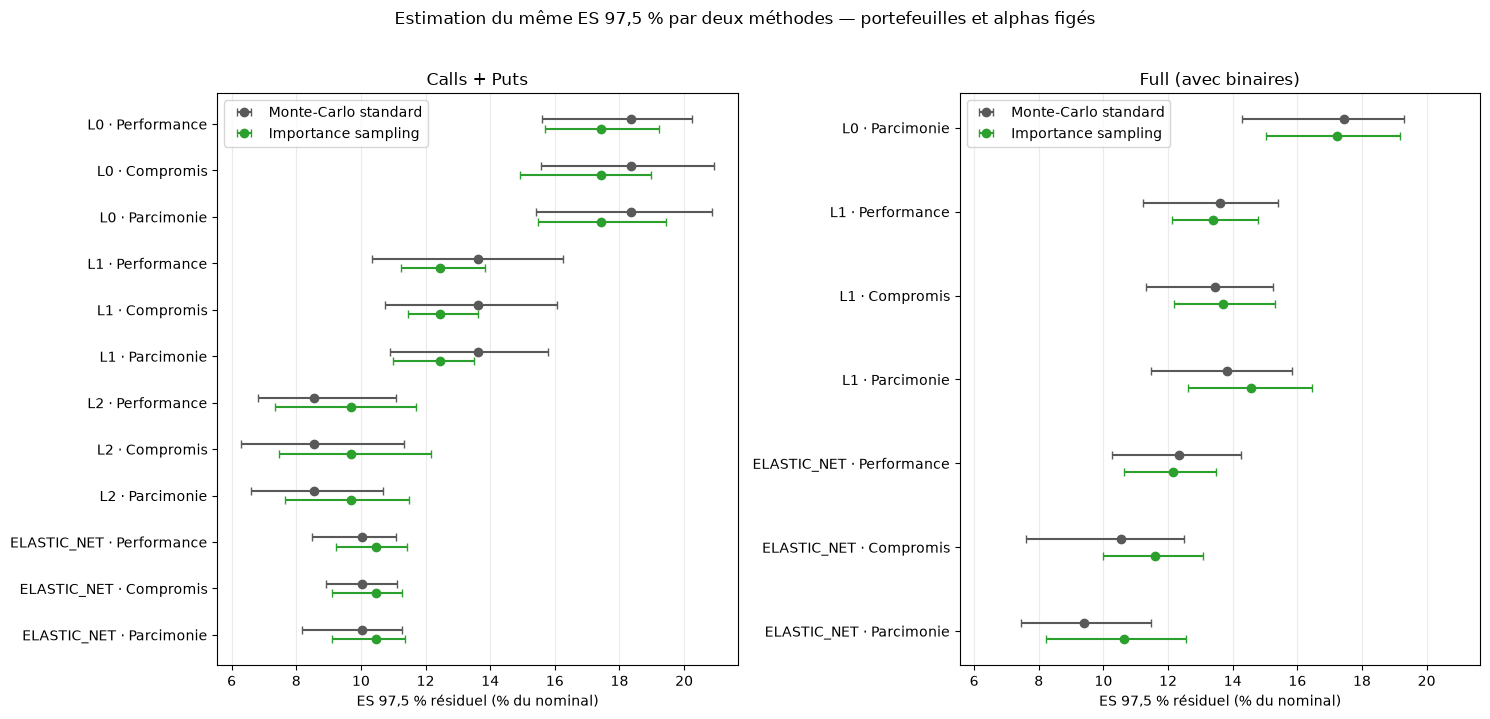

Une valeur plus élevée ne signifie pas que l’importance sampling dégrade la couverture ; elle indique une estimation différente du même risque de queue.


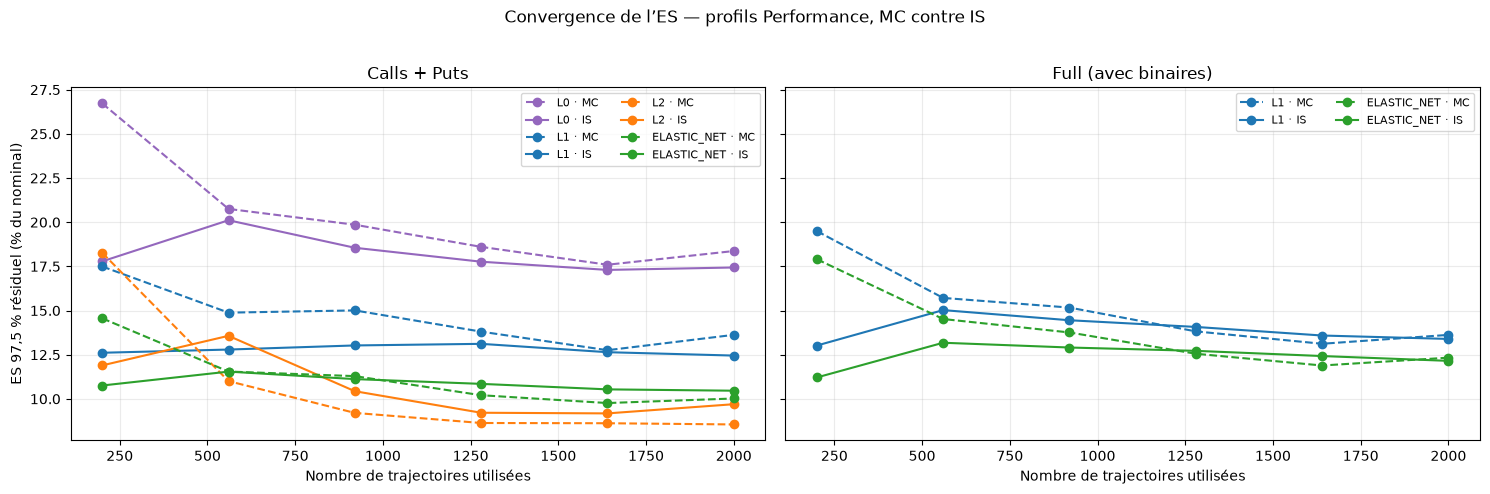

In [26]:
# Deuxième moteur d'évaluation : les poids financiers restent figés.
import importlib
import autocall_replication.replication.importance_sampling as _importance_sampling_module
_importance_sampling_module = importlib.reload(_importance_sampling_module)

from autocall_replication.replication.importance_sampling import (
    DEFAULT_IMPORTANCE_MIXTURE,
    DEFAULT_IMPORTANCE_TILTS,
    bootstrap_expected_shortfall_interval,
    compare_standard_and_importance_risk,
    evaluate_conditional_policy_profile_risk_importance,
    weighted_tail_risk_metrics,
)
from autocall_replication.replication.risk import tail_risk_metrics

importance_risk_results = {}
importance_risk_result = None
importance_comparison = pd.DataFrame()
importance_ci_table = pd.DataFrame()

if not RUN_IMPORTANCE_SAMPLING:
    print("Importance sampling désactivé dans la configuration.")
elif risk_result is None:
    print("Importance sampling non calculé : aucun profil stable évalué par le moteur standard.")
else:
    for family, stable_result in stable_profile_results.items():
        if stable_result["profiles"].empty or family not in conditional_risk_results:
            continue
        importance_risk_results[family] = evaluate_conditional_policy_profile_risk_importance(
            base_result=stable_result,
            product=prod,
            spot0=spot0,
            valuation_date=valuation_date,
            maturity_date=maturity_date,
            rate=rate,
            dividend_yield=dividend_yield,
            vol=vol,
            n_paths=CFG["risk_paths"],
            seed=20500,
            min_condition_observations=200,
            tilts=DEFAULT_IMPORTANCE_TILTS,
            mixture_probabilities=DEFAULT_IMPORTANCE_MIXTURE,
        )

    if importance_risk_results:
        importance_risk_result = {
            "comparison": pd.concat([result["comparison"] for result in importance_risk_results.values()], ignore_index=True),
            "conditional_comparison": pd.concat([result["conditional_comparison"] for result in importance_risk_results.values()], ignore_index=True),
            "risk_summary": pd.concat([result["risk_summary"] for result in importance_risk_results.values()], ignore_index=True),
        }
        importance_comparison = compare_standard_and_importance_risk(
            standard_summary=risk_result["comparison"],
            importance_summary=importance_risk_result["comparison"],
        )

        print("Statut méthodologique : mêmes poids financiers, deux estimateurs de risque indépendants.")
        display(pd.Series({
            "poids financiers": "figés avant les deux évaluations",
            "calibration par importance sampling": "non",
            "trajectoires par méthode et famille": CFG["risk_paths"],
            "déformations terminales": DEFAULT_IMPORTANCE_TILTS,
            "probabilités du mélange": DEFAULT_IMPORTANCE_MIXTURE,
            "mesure cible": "GBM risque-neutre inchangé",
        }, name="comparaison MC / IS"))

        diagnostic_rows = []
        component_tables = []
        for family, result in importance_risk_results.items():
            diagnostic_rows.append({"family": FAMILY_LABELS[family], **result["sampling_diagnostics"]})
            component_tables.append(result["component_summary"].assign(family=FAMILY_LABELS[family]))
        print("Diagnostic des poids statistiques :")
        display(pd.DataFrame(diagnostic_rows))
        display(pd.concat(component_tables, ignore_index=True))

        comparison_columns = [
            "family", "penalty", "profile",
            "standard_residual_rmse", "importance_residual_rmse",
            "standard_residual_es_95", "importance_residual_es_95",
            "standard_residual_es_975", "importance_residual_es_975",
            "standard_residual_es_99", "importance_residual_es_99",
        ]
        print("Comparaison directe des estimateurs — aucune recalibration du portefeuille :")
        display(importance_comparison[[column for column in comparison_columns if column in importance_comparison]])

        ci_rows = []
        for family, importance_result in importance_risk_results.items():
            standard_result = conditional_risk_results[family]
            for profile_key, standard_losses in standard_result["profile_losses"].items():
                if profile_key not in importance_result["profile_losses"]:
                    continue
                penalty, profile = profile_key
                standard_ci = bootstrap_expected_shortfall_interval(
                    standard_losses, level=0.975, n_bootstrap=CFG["importance_bootstrap"],
                    seed=31000 + len(ci_rows),
                )
                importance_ci = bootstrap_expected_shortfall_interval(
                    importance_result["profile_losses"][profile_key], level=0.975,
                    likelihood_weights=importance_result["likelihood_weights"],
                    n_bootstrap=CFG["importance_bootstrap"], seed=41000 + len(ci_rows),
                )
                scale = 100.0 / float(prod.notional)
                ci_rows.append({
                    "family": family, "penalty": penalty, "profile": profile,
                    "standard_es_975_pct_notional": standard_ci["estimate"] * scale,
                    "standard_ci_low": standard_ci["ci_low"] * scale,
                    "standard_ci_high": standard_ci["ci_high"] * scale,
                    "importance_es_975_pct_notional": importance_ci["estimate"] * scale,
                    "importance_ci_low": importance_ci["ci_low"] * scale,
                    "importance_ci_high": importance_ci["ci_high"] * scale,
                    "confidence_intervals_overlap": max(standard_ci["ci_low"], importance_ci["ci_low"]) <= min(standard_ci["ci_high"], importance_ci["ci_high"]),
                })
        importance_ci_table = pd.DataFrame(ci_rows)
        importance_ci_table["is_minus_mc_pct_notional"] = (
            importance_ci_table["importance_es_975_pct_notional"] - importance_ci_table["standard_es_975_pct_notional"]
        )
        importance_ci_table["standard_ci_width"] = importance_ci_table["standard_ci_high"] - importance_ci_table["standard_ci_low"]
        importance_ci_table["importance_ci_width"] = importance_ci_table["importance_ci_high"] - importance_ci_table["importance_ci_low"]
        importance_ci_table["ci_width_change"] = importance_ci_table["importance_ci_width"] - importance_ci_table["standard_ci_width"]
        print("Expected Shortfall 97,5 % et intervalles de confiance bootstrap :")
        display(importance_ci_table)
        print("Lecture condensée — écart d’estimation et largeur des intervalles :")
        importance_precision_table = importance_ci_table[[
            "family", "penalty", "profile", "is_minus_mc_pct_notional",
            "standard_ci_width", "importance_ci_width", "ci_width_change",
            "confidence_intervals_overlap",
        ]].rename(columns={
            "family": "Famille", "penalty": "Pénalité", "profile": "Profil",
            "is_minus_mc_pct_notional": "Écart IS − MC (point de nominal)",
            "standard_ci_width": "Largeur IC Monte-Carlo",
            "importance_ci_width": "Largeur IC importance sampling",
            "ci_width_change": "Variation de largeur (IS − MC)",
            "confidence_intervals_overlap": "Intervalles compatibles",
        })
        display(importance_precision_table)

        # Vue principale : mêmes politiques, estimateurs et incertitudes côte à côte.
        fig, comparison_axes = plt.subplots(1, len(MAIN_FAMILIES), figsize=(15, 7), sharex=True)
        comparison_axes = np.atleast_1d(comparison_axes)
        for axis, family in zip(comparison_axes, MAIN_FAMILIES):
            family_ci = importance_ci_table.loc[importance_ci_table["family"] == family].copy()
            family_ci["candidate"] = (
                family_ci["penalty"].str.upper() + " · " + family_ci["profile"].map({"performance": "Performance", "compromise": "Compromis", "parsimony": "Parcimonie"})
            )
            y_positions = np.arange(len(family_ci), dtype=float)
            standard_values = family_ci["standard_es_975_pct_notional"].to_numpy()
            importance_values = family_ci["importance_es_975_pct_notional"].to_numpy()
            axis.errorbar(
                standard_values, y_positions - 0.10,
                xerr=np.vstack([standard_values - family_ci["standard_ci_low"], family_ci["standard_ci_high"] - standard_values]),
                fmt="o", color="0.35", capsize=3, label="Monte-Carlo standard",
            )
            axis.errorbar(
                importance_values, y_positions + 0.10,
                xerr=np.vstack([importance_values - family_ci["importance_ci_low"], family_ci["importance_ci_high"] - importance_values]),
                fmt="o", color="tab:green", capsize=3, label="Importance sampling",
            )
            axis.set_yticks(y_positions)
            axis.set_yticklabels(family_ci["candidate"])
            axis.invert_yaxis()
            axis.set_title(FAMILY_LABELS[family])
            axis.set_xlabel("ES 97,5 % résiduel (% du nominal)")
            axis.grid(axis="x", alpha=0.25)
            axis.legend()
        fig.suptitle("Estimation du même ES 97,5 % par deux méthodes — portefeuilles et alphas figés", y=1.02)
        fig.tight_layout()
        RUN_FIGURES["importance_sampling_es"] = fig
        plt.show()
        print("Une valeur plus élevée ne signifie pas que l’importance sampling dégrade la couverture ; elle indique une estimation différente du même risque de queue.")

        # Convergence illustrative : profil Performance de chaque pénalité.
        fig, convergence_axes = plt.subplots(1, len(MAIN_FAMILIES), figsize=(15, 4.8), sharey=True)
        convergence_axes = np.atleast_1d(convergence_axes)
        method_styles = {"standard": "--", "importance": "-"}
        method_names = {"standard": "MC", "importance": "IS"}
        risk_colors = {"l0": "tab:purple", "l1": "tab:blue", "l2": "tab:orange", "elastic_net": "tab:green"}
        for axis, family in zip(convergence_axes, MAIN_FAMILIES):
            standard_result = conditional_risk_results[family]
            importance_result = importance_risk_results[family]
            sample_sizes = np.unique(np.linspace(max(100, CFG["risk_paths"] // 10), CFG["risk_paths"], 6, dtype=int))
            for profile_key, standard_losses in standard_result["profile_losses"].items():
                penalty, profile = profile_key
                if profile != "performance" or profile_key not in importance_result["profile_losses"]:
                    continue
                standard_curve = [tail_risk_metrics(standard_losses[:n], levels=(0.975,))["es_975"] * 100.0 / prod.notional for n in sample_sizes]
                importance_curve = [weighted_tail_risk_metrics(importance_result["profile_losses"][profile_key][:n], importance_result["likelihood_weights"][:n], levels=(0.975,))["es_975"] * 100.0 / prod.notional for n in sample_sizes]
                penalty_color = risk_colors.get(penalty, "tab:gray")
                axis.plot(sample_sizes, standard_curve, linestyle=method_styles["standard"], color=penalty_color, marker="o", label=f"{penalty.upper()} · {method_names['standard']}")
                axis.plot(sample_sizes, importance_curve, linestyle=method_styles["importance"], color=penalty_color, marker="o", label=f"{penalty.upper()} · {method_names['importance']}")
            axis.set_title(FAMILY_LABELS[family])
            axis.set_xlabel("Nombre de trajectoires utilisées")
            axis.grid(alpha=0.25)
            axis.legend(ncol=2, fontsize=8)
        convergence_axes[0].set_ylabel("ES 97,5 % résiduel (% du nominal)")
        fig.suptitle("Convergence de l’ES — profils Performance, MC contre IS", y=1.02)
        fig.tight_layout()
        RUN_FIGURES["importance_sampling_convergence"] = fig
        plt.show()


### 6.4 Niveau 3 — future couverture dynamique du résidu

La prochaine phase construira une stratégie autofinancée appliquée à $H_0-R_0$. Elle ajoutera les gains du sous-jacent, le compte cash, les rebalancements, la liquidation au rappel et les coûts correspondants :

$$E_{\mathrm{final}} = H_0 - R_0 - G_0^{\mathrm{hedge}}.$$

Aucun chiffre de cette section ne doit encore être présenté comme un risque après couverture dynamique. Le statut reste `level_3_not_implemented`.


## 7. Coût et financement de la politique conditionnelle

### 7.1 Formules, trois traitements des binaires et ledger autofinancé

L’émetteur reçoit la prime de l’autocall, achète le premier panier, puis utilise les payoffs des options et le compte cash pour payer le client et financer le panier suivant. Un cash négatif représente un emprunt au taux sans risque ; aucune injection n’est ajoutée silencieusement.

Pour $T$ années restantes :

$$d_1=\frac{\ln(S_t/K)+(r-q+\frac12\sigma^2)T}{\sigma\sqrt{T}},\qquad d_2=d_1-\sigma\sqrt{T}.$$

$$C_t=S_te^{-qT}N(d_1)-Ke^{-rT}N(d_2),$$

$$P_t=Ke^{-rT}N(-d_2)-S_te^{-qT}N(-d_1).$$

Pour une binaire cash-or-nothing de payout $Q$ :

$$BC_t=Qe^{-rT}N(d_2),\qquad BP_t=Qe^{-rT}N(-d_2).$$

La valeur nette et l’exposition brute d’un panier sont séparées :

$$V_t^{\mathrm{panier}}=\sum_j w_{t,j}V_{t,j},\qquad E_t^{\mathrm{brute}}=\sum_j |w_{t,j}V_{t,j}|.$$

Trois traitements des binaires sont comparés :

1. **Full théorique** : la binaire exacte est valorisée par Black-Scholes.
2. **Full transformé en spreads** : chaque binaire est remplacée par une rampe de calls ou puts, puis son payoff, son risque et son financement sont recalculés. Pour $K_1<K<K_2$ :

$$BC(K)\approx\frac{Q}{K_2-K_1}[C(K_1)-C(K_2)],$$

$$BP(K)\approx\frac{Q}{K_2-K_1}[P(K_2)-P(K_1)].$$

3. **Full OTC** : le payoff binaire exact est conservé avec une charge provisoire de 5, 10 ou 25 bps du payout pour les scénarios favorable, central et stressé. Pour le moment, ces charges sont des hypothèses et non des cotations de dealer.

Le bid-ask des options listées et le spread vertical observable sont volontairement reportés. Cette section utilise les prix Black-Scholes mid, sauf pour les charges OTC explicites.

La récurrence du compte cash est :

$$C_{t_i}^{-}=C_{t_{i-1}}^{+}e^{r\Delta t_i},$$

$$C_{t_i}^{\mathrm{règlement}}=C_{t_i}^{-}+P_{t_i}^{\mathrm{options}}-H_{t_i}^{\mathrm{autocall}},$$

$$C_{t_i}^{+}=C_{t_i}^{\mathrm{règlement}}-V_{t_i}^{\mathrm{panier\ suivant}}.$$

En cas de rappel, aucun panier suivant n’est acheté et le cash restant devient le P&L final.


Coût, financement et P&L — échantillon indépendant, alpha et poids figés :


,family,penalty,profile,implementation,initial_net_cost_mean,initial_gross_exposure_mean,borrowing_frequency,additional_capital_p95,terminal_pnl_mean,loss_es_975,cumulative_otc_execution_cost_mean
0,calls_puts,l0,performance,Calls + Puts calibré,101.216378,101.216378,1.0,4.421897,0.047692,12.965923,0.000000
1,calls_puts,l0,compromise,Calls + Puts calibré,101.216378,101.216378,1.0,4.421897,0.047692,12.965923,0.000000
2,calls_puts,l0,parsimony,Calls + Puts calibré,101.216378,101.216378,1.0,4.421897,0.047692,12.965923,0.000000
3,calls_puts,l1,performance,Calls + Puts calibré,101.216358,101.216358,1.0,4.370324,0.018078,10.923127,0.000000
4,calls_puts,l1,compromise,Calls + Puts calibré,101.216358,101.216358,1.0,4.370324,0.018078,10.923127,0.000000
5,calls_puts,l1,parsimony,Calls + Puts calibré,101.216358,101.216358,1.0,4.370324,0.018078,10.923127,0.000000
6,calls_puts,l2,performance,Calls + Puts calibré,101.215069,101.215069,1.0,4.653523,0.288744,4.663336,0.000000
7,calls_puts,l2,compromise,Calls + Puts calibré,101.215069,101.215069,1.0,4.653523,0.288744,4.663336,0.000000
8,calls_puts,l2,parsimony,Calls + Puts calibré,101.215021,101.215021,1.0,4.653842,0.289119,4.659385,0.000000
9,calls_puts,elastic_net,performance,Calls + Puts calibré,101.216552,101.216552,1.0,4.322547,0.060794,7.255884,0.000000


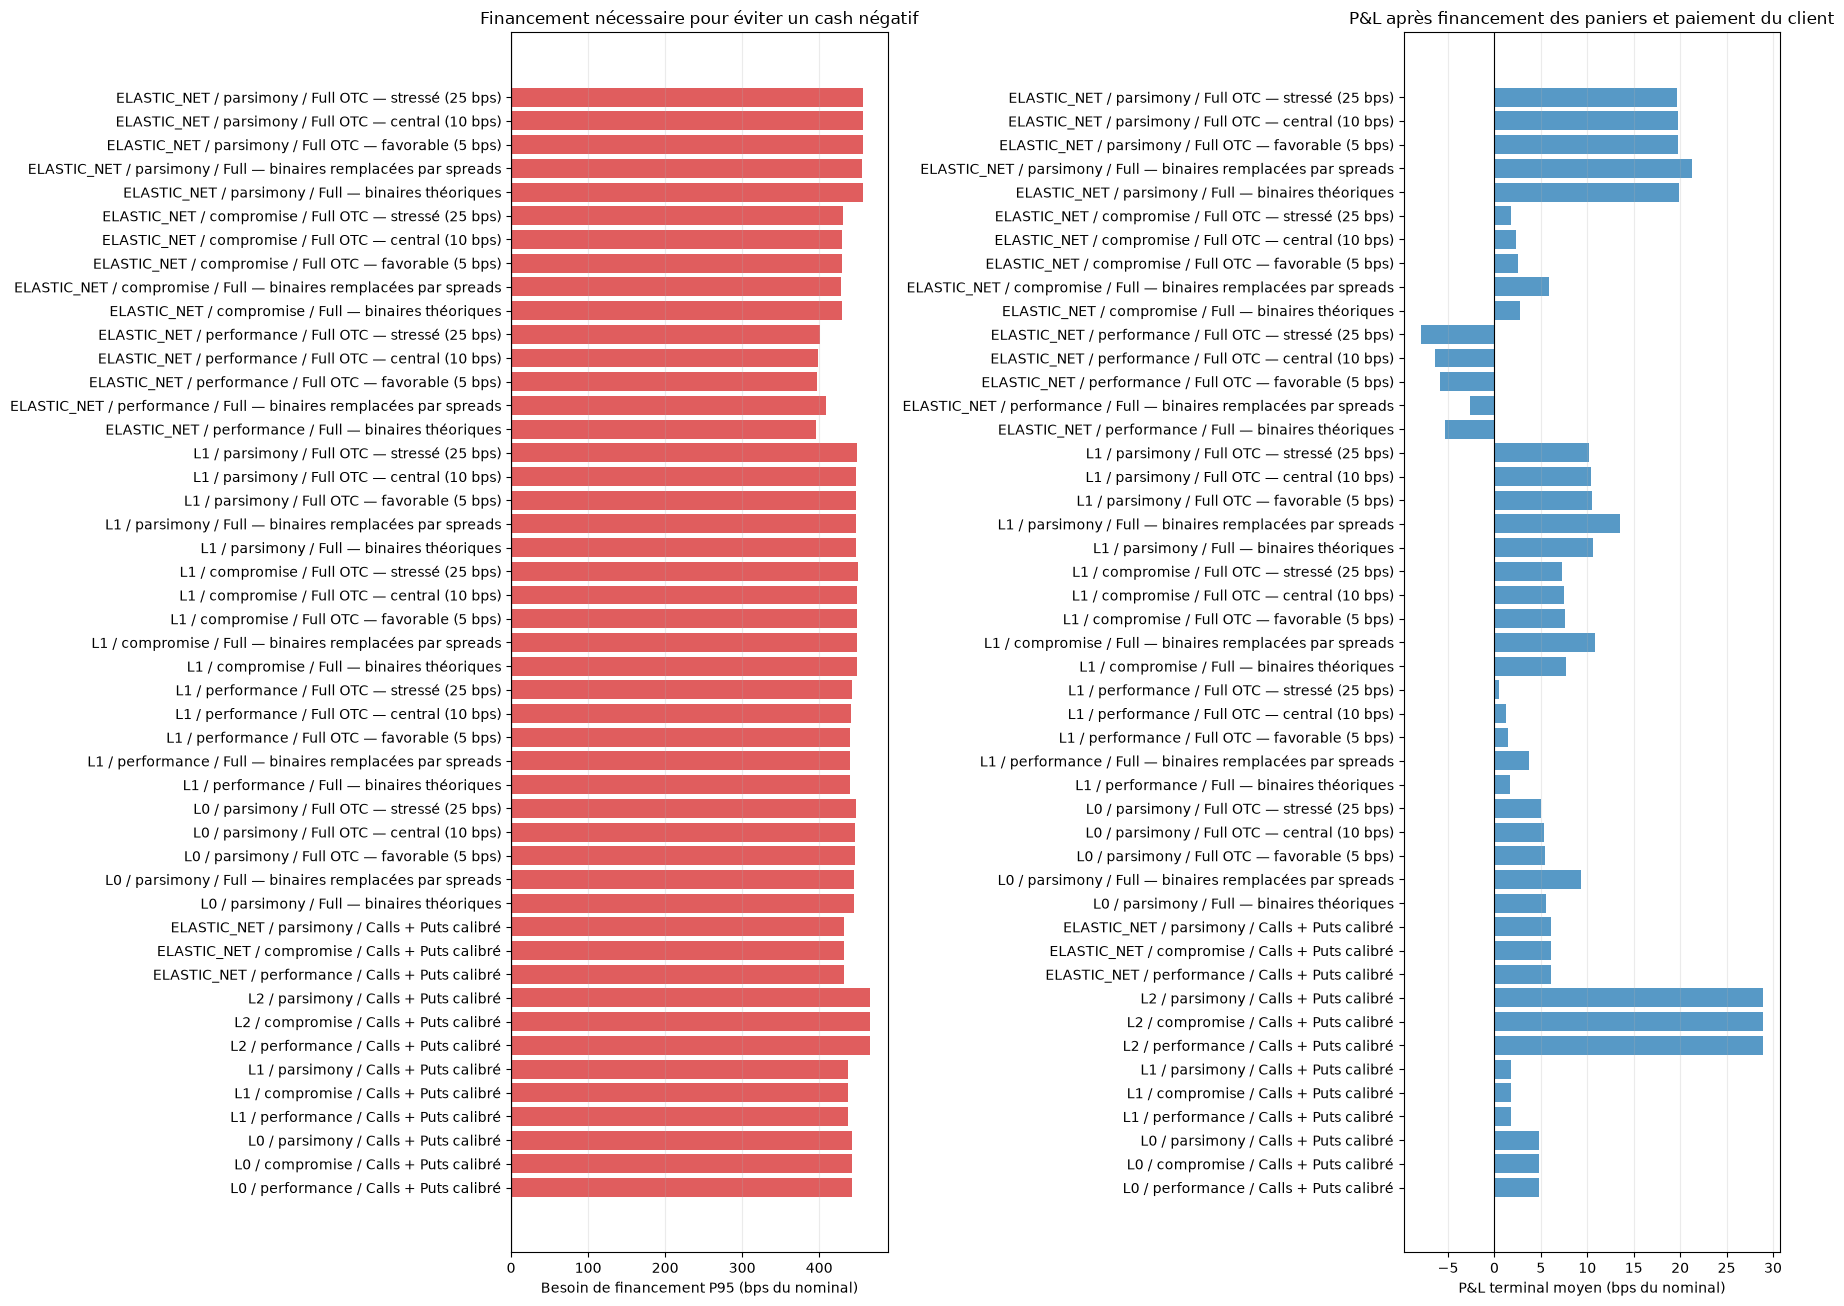

Ledger d'une trajectoire rappelée :


,family,penalty,profile,path_id,event_date,event_type,spot,binary_mode,autocall_premium,cash_before_event,...,autocall_cashflow,next_node_index,next_portfolio_net_model_value,next_portfolio_net_execution_value,next_portfolio_gross_exposure,otc_execution_cost,cash_after_event,running_min_cash,recalled,new_position_opened
12000,full,l0,parsimony,0,2026-06-20,initial_hedge_purchase,100.000000,theoretical,100.36289,100.362890,...,0.0,0.0,101.217632,101.217632,101.217632,0.0,-0.854742,-0.854742,False,True
12001,full,l0,parsimony,0,2026-09-22,observation_settlement,100.246935,theoretical,0.00000,-0.854742,...,102.0,NaN,0.000000,0.000000,0.000000,0.0,-0.858700,-0.858700,True,False
12002,full,l0,parsimony,0,2026-12-22,observation_settlement,99.113223,theoretical,0.00000,-0.858700,...,0.0,NaN,0.000000,0.000000,0.000000,0.0,-0.865147,-0.865147,False,False
12003,full,l0,parsimony,0,2027-03-22,observation_settlement,105.160588,theoretical,0.00000,-0.865147,...,0.0,NaN,0.000000,0.000000,0.000000,0.0,-0.871570,-0.871570,False,False
12004,full,l0,parsimony,0,2027-06-22,observation_settlement,125.064724,theoretical,0.00000,-0.871570,...,0.0,NaN,0.000000,0.000000,0.000000,0.0,-0.878186,-0.878186,False,False


Ledger d'une trajectoire jusqu'à maturité :


,family,penalty,profile,path_id,event_date,event_type,spot,binary_mode,autocall_premium,cash_before_event,...,autocall_cashflow,next_node_index,next_portfolio_net_model_value,next_portfolio_net_execution_value,next_portfolio_gross_exposure,otc_execution_cost,cash_after_event,running_min_cash,recalled,new_position_opened
12005,full,l0,parsimony,1,2026-06-20,initial_hedge_purchase,100.000000,theoretical,100.36289,100.362890,...,0.0,0.0,101.217632,101.217632,101.217632,0.0,-0.854742,-0.854742,False,True
12006,full,l0,parsimony,1,2026-09-22,observation_settlement,95.399412,theoretical,0.00000,-0.854742,...,2.0,2.0,1.195083,1.195083,1.195083,0.0,97.946216,-0.854742,False,True
12007,full,l0,parsimony,1,2026-12-22,observation_settlement,93.058380,theoretical,0.00000,97.946216,...,2.0,4.0,1.370010,1.370010,1.370010,0.0,96.515593,-0.854742,False,True
12008,full,l0,parsimony,1,2027-03-22,observation_settlement,94.142075,theoretical,0.00000,96.515593,...,2.0,6.0,0.213325,0.213325,0.848727,0.0,96.399047,-0.854742,False,True
12009,full,l0,parsimony,1,2027-06-22,observation_settlement,97.108982,theoretical,0.00000,96.399047,...,102.0,NaN,0.000000,0.000000,0.000000,0.0,-4.334198,-4.334198,False,False


In [27]:
from autocall_replication.replication.funding import (
    BINARY_MODES,
    evaluate_conditional_policy_funding,
)

BINARY_MODE_LABELS = {
    "no_binaries": "Calls + Puts calibré",
    "theoretical": "Full — binaires théoriques",
    "vertical_spread": "Full — binaires remplacées par spreads",
    "otc_favorable": "Full OTC — favorable (5 bps)",
    "otc_central": "Full OTC — central (10 bps)",
    "otc_stressed": "Full OTC — stressé (25 bps)",
}
VERTICAL_SPREAD_WIDTH = 5.0
funding_results = {}
for family, stable_result in stable_profile_results.items():
    if stable_result["profiles"].empty:
        print(f"{FAMILY_LABELS[family]} : aucun profil stable à financer.")
        continue
    funding_results[family] = evaluate_conditional_policy_funding(
        base_result=stable_result, product=prod, spot0=spot0,
        valuation_date=valuation_date, maturity_date=maturity_date,
        rate=rate, dividend_yield=dividend_yield, vol=vol,
        n_paths=CFG["funding_paths"], seed=20500,
        initial_autocall_premium=pricing_result["actualized_price"],
        spread_width=VERTICAL_SPREAD_WIDTH,
    )

if not funding_results:
    funding_summary = pd.DataFrame()
    funding_path_summary = pd.DataFrame()
    funding_ledger = pd.DataFrame()
    print("Financement non calculé : aucun profil stable.")
else:
    funding_summary = pd.concat([result["summary"] for result in funding_results.values()], ignore_index=True)
    funding_path_summary = pd.concat([result["path_summary"] for result in funding_results.values()], ignore_index=True)
    funding_ledger = pd.concat([result["ledger"] for result in funding_results.values()], ignore_index=True)
    funding_summary["implementation"] = funding_summary["binary_mode"].map(BINARY_MODE_LABELS)

    funding_columns = [
        "family", "penalty", "profile", "implementation",
        "initial_net_cost_mean", "initial_gross_exposure_mean",
        "borrowing_frequency", "additional_capital_p95",
        "terminal_pnl_mean", "loss_es_975",
        "cumulative_otc_execution_cost_mean",
    ]
    print("Coût, financement et P&L — échantillon indépendant, alpha et poids figés :")
    display(funding_summary[funding_columns])

    plot_table = funding_summary.copy()
    plot_table["candidate"] = (
        plot_table["penalty"].str.upper() + " / " + plot_table["profile"]
        + " / " + plot_table["implementation"]
    )
    x = np.arange(len(plot_table))
    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.28 * len(plot_table))))
    axes[0].barh(x, plot_table["additional_capital_p95_bps_notional"], color="tab:red", alpha=0.75)
    axes[0].set_yticks(x, plot_table["candidate"])
    axes[0].set_xlabel("Besoin de financement P95 (bps du nominal)")
    axes[0].set_title("Financement nécessaire pour éviter un cash négatif")
    axes[1].barh(x, plot_table["terminal_pnl_mean_bps_notional"], color="tab:blue", alpha=0.75)
    axes[1].set_yticks(x, plot_table["candidate"])
    axes[1].set_xlabel("P&L terminal moyen (bps du nominal)")
    axes[1].set_title("P&L après financement des paniers et paiement du client")
    for axis in axes:
        axis.axvline(0.0, color="black", linewidth=0.8)
        axis.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    RUN_FIGURES["funding_and_terminal_pnl"] = fig
    plt.show()

    # Deux ledgers lisibles : un rappel et une trajectoire allant à maturité.
    _example_paths = funding_path_summary.loc[
        (funding_path_summary["family"] == "full")
        & (funding_path_summary["binary_mode"] == "theoretical")
    ]
    if not _example_paths.empty:
        _example_profile = _example_paths.iloc[0][["penalty", "profile"]]
        for _condition_name, _condition_mask in {
            "rappelée": _example_paths["called"],
            "jusqu'à maturité": ~_example_paths["called"],
        }.items():
            _eligible = _example_paths.loc[
                _condition_mask
                & (_example_paths["penalty"] == _example_profile["penalty"])
                & (_example_paths["profile"] == _example_profile["profile"])
            ]
            if not _eligible.empty:
                _path_id = int(_eligible.iloc[0]["path_id"])
                print(f"Ledger d'une trajectoire {_condition_name} :")
                display(funding_ledger.loc[
                    (funding_ledger["family"] == "full")
                    & (funding_ledger["penalty"] == _example_profile["penalty"])
                    & (funding_ledger["profile"] == _example_profile["profile"])
                    & (funding_ledger["binary_mode"] == "theoretical")
                    & (funding_ledger["path_id"] == _path_id)
                ])


### 7.2 Trois prix et benchmark de comparaison

Cette section répond à deux questions différentes, sans les mélanger :

1. **Est-ce que notre réplication réduit le risque ?** Le RMSE et l’Expected Shortfall 97,5 % résiduels sont comparés au produit non couvert, puis à la famille liquide `calls_puts`, à pénalité et profil identiques.
2. **Notre prix laisse-t-il un coussin économique comparable aux pratiques documentées ?** Trois prix sont séparés :
   - prix théorique : valeur du passif sous le modèle ;
   - prix minimal de couverture : prime qui annule le P&L terminal moyen estimé ;
   - prix commercial indicatif : prix minimal augmenté d’une marge cible explicite.

Le benchmark externe utilise uniquement l’écart public entre prix d’émission et valeur initiale estimée par l’émetteur. Cet écart contient commissions, structuration, coûts de couverture et profits projetés : **ce n’est pas le P&L réalisé d’un desk**. Les produits publics ne sont pas identiques au nôtre ; le benchmark est donc documentaire et non une validation statistique de performance.


In [28]:
from autocall_replication.replication.industry_benchmark import (
    build_internal_hedge_benchmark,
    build_three_price_table,
    compare_commercial_cushion_to_public_benchmark,
    public_structured_note_pricing_benchmark,
)

TARGET_COMMERCIAL_MARGIN_PCT_NOTIONAL = 1.0  # hypothèse, pas une donnée de marché
public_pricing_benchmark = public_structured_note_pricing_benchmark()
internal_hedge_benchmark = pd.DataFrame()
three_price_summary = pd.DataFrame()
pricing_benchmark_summary = None

if risk_result is not None and not risk_result["risk_summary"].empty:
    internal_hedge_benchmark = build_internal_hedge_benchmark(
        risk_result["risk_summary"], reference_family="calls_puts"
    )
    print("Benchmark technique — amélioration positive = risque réduit :")
    display(internal_hedge_benchmark[[
        "family", "penalty", "profile",
        "residual_rmse", "rmse_improvement_vs_unhedged",
        "rmse_improvement_vs_reference",
        "residual_es_975", "es_975_improvement_vs_unhedged",
        "es_975_improvement_vs_reference",
    ]])

if funding_summary.empty:
    print("Trois prix non calculés : aucune stratégie financée.")
else:
    _price_frames = []
    for _, _funding_row in funding_summary.iterrows():
        _prices = build_three_price_table(
            funding_row=_funding_row,
            theoretical_price=pricing_result["actualized_price"],
            notional=prod.notional,
            target_margin_pct_notional=TARGET_COMMERCIAL_MARGIN_PCT_NOTIONAL,
        )
        for _column in ["family", "penalty", "profile", "binary_mode", "implementation"]:
            _prices[_column] = _funding_row[_column]
        _price_frames.append(_prices)
    three_price_summary = pd.concat(_price_frames, ignore_index=True)

    # Candidat illustratif : Full / spread vertical / L1 / compromis si disponible.
    _representative_mask = (
        three_price_summary["family"].eq("full")
        & three_price_summary["binary_mode"].eq("vertical_spread")
        & three_price_summary["penalty"].eq("l1")
        & three_price_summary["profile"].eq("compromise")
    )
    representative_prices = three_price_summary.loc[_representative_mask].copy()
    if representative_prices.empty:
        _first_candidate = three_price_summary.iloc[0][["family", "penalty", "profile", "binary_mode"]]
        representative_prices = three_price_summary.loc[
            (three_price_summary[["family", "penalty", "profile", "binary_mode"]] == _first_candidate).all(axis=1)
        ].copy()

    pricing_benchmark_summary = compare_commercial_cushion_to_public_benchmark(
        representative_prices, public_pricing_benchmark
    )
    print("Les trois prix du candidat représentatif :")
    display(representative_prices[[
        "price_type", "price", "price_pct_notional",
        "cushion_vs_theoretical_pct_notional", "definition",
    ]])
    print("Positionnement face aux exemples publics :")
    display(pricing_benchmark_summary)

print("Exemples publics documentés — écarts de prix, pas P&L de desk :")
display(public_pricing_benchmark[[
    "issuer", "document_date", "structure",
    "gap_pct_low", "gap_pct_high", "source_url",
]])


Benchmark technique — amélioration positive = risque réduit :


,family,penalty,profile,residual_rmse,rmse_improvement_vs_unhedged,rmse_improvement_vs_reference,residual_es_975,es_975_improvement_vs_unhedged,es_975_improvement_vs_reference
0,calls_puts,l0,performance,3.709649,0.517794,0.000000,18.368552,-3.182470,0.000000
1,calls_puts,l0,compromise,3.709649,0.517794,0.000000,18.368552,-3.182470,0.000000
2,calls_puts,l0,parsimony,3.709649,0.517794,0.000000,18.368552,-3.182470,0.000000
3,calls_puts,l1,performance,2.953123,0.616133,0.000000,13.623559,-2.102047,0.000000
4,calls_puts,l1,compromise,2.953123,0.616133,0.000000,13.623559,-2.102047,0.000000
5,calls_puts,l1,parsimony,2.953123,0.616133,0.000000,13.623559,-2.102047,0.000000
6,calls_puts,l2,performance,5.831716,0.241954,0.000000,8.552201,-0.947313,0.000000
7,calls_puts,l2,compromise,5.831716,0.241954,0.000000,8.552201,-0.947313,0.000000
8,calls_puts,l2,parsimony,5.838350,0.241091,0.000000,8.549242,-0.946639,0.000000
9,calls_puts,elastic_net,performance,2.614266,0.660180,0.000000,10.021125,-1.281783,0.000000


Les trois prix du candidat représentatif :


,price_type,price,price_pct_notional,cushion_vs_theoretical_pct_notional,definition
69,theoretical,100.362890,100.362890,0.000000,valeur du passif sous le modèle
70,minimum_coverage,100.254522,100.254522,-0.108368,prix annulant le P&L terminal moyen estimé
71,commercial,101.254522,101.254522,0.891632,prix minimal + marge cible de 1.00% du nominal


Positionnement face aux exemples publics :


our_commercial_cushion_pct_notional                                                0.891632
public_example_gap_min_pct                                                             2.45
public_example_gap_mid_median_pct                                                     6.225
public_example_gap_max_pct                                                             11.0
our_cushion_vs_public_mid_median_ratio                                             0.143234
interpretation_limit                      public gaps include distribution, structuring,...
Name: pricing_benchmark, dtype: object

Exemples publics documentés — écarts de prix, pas P&L de desk :


,issuer,document_date,structure,gap_pct_low,gap_pct_high,source_url
0,JPMorgan,2025-04-09,Auto Callable Notes,2.84,2.84,https://www.sec.gov/Archives/edgar/data/19617/...
1,Barclays,2025-11-24,Auto-Callable Notes,6.00,6.00,https://www.sec.gov/Archives/edgar/data/312070...
2,Morgan Stanley,2026-05-14,Jump Notes with Auto-Callable Feature,2.45,10.45,https://www.sec.gov/Archives/edgar/data/895421...
3,Goldman Sachs,2025-05-01,Autocallable Contingent Coupon Notes,8.00,11.00,https://www.sec.gov/Archives/edgar/data/000088...


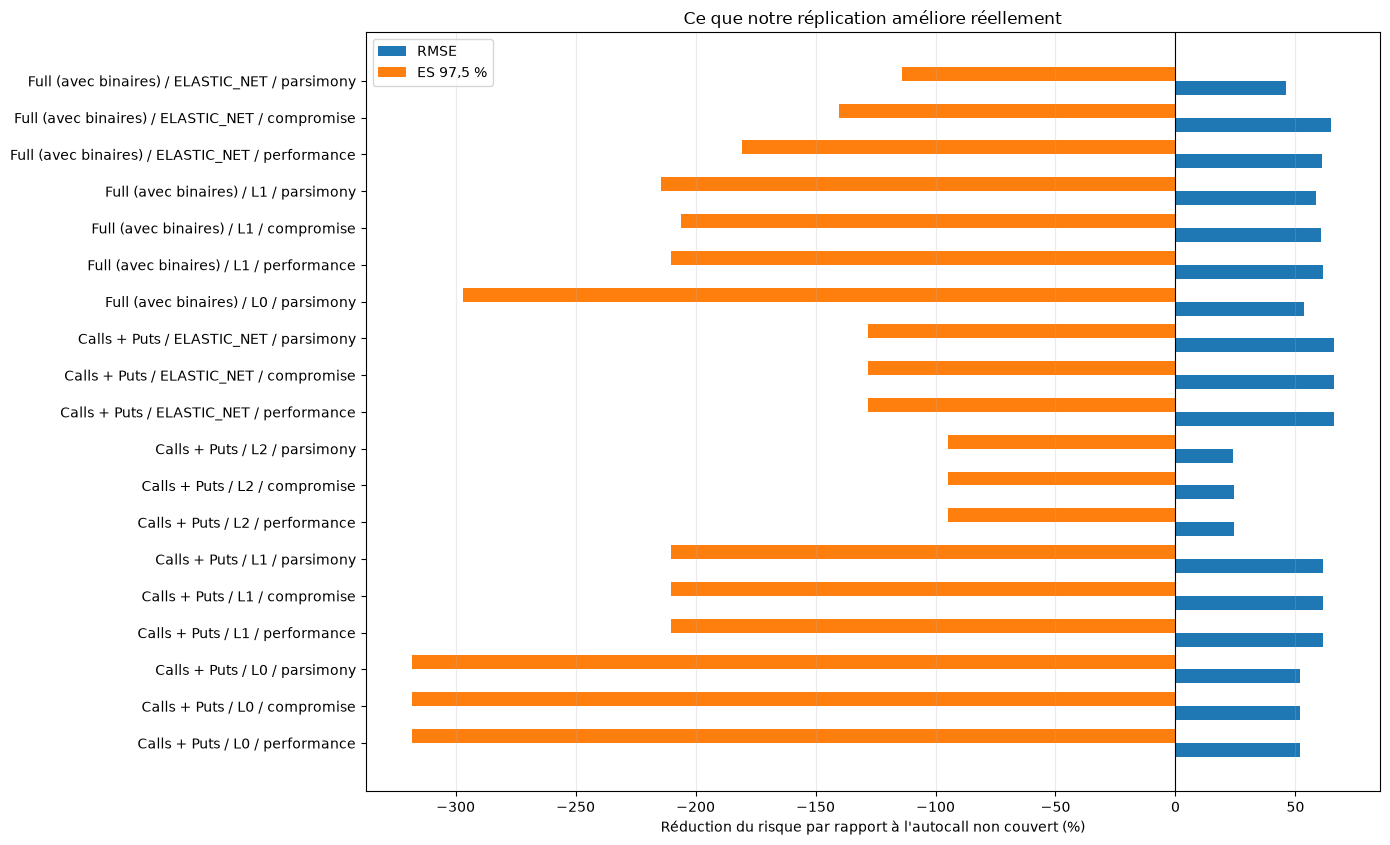

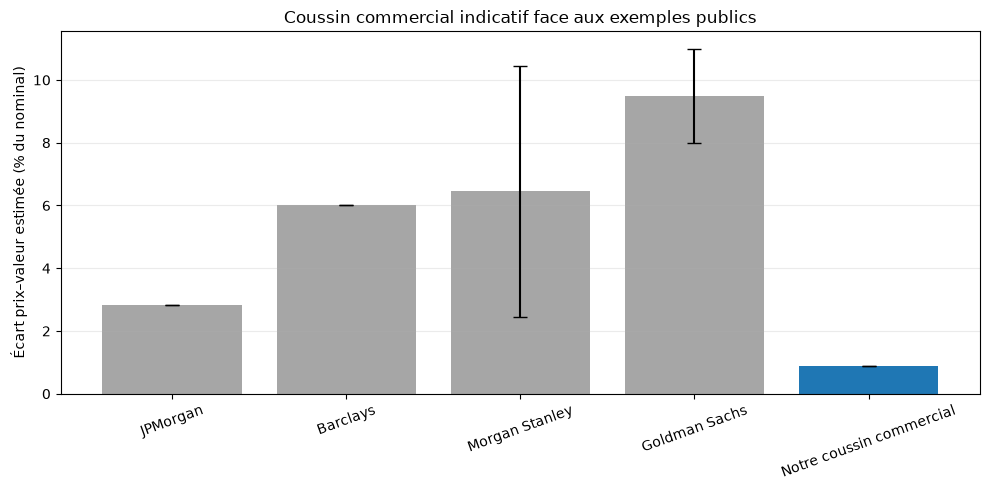

In [29]:
if not internal_hedge_benchmark.empty:
    _chart = internal_hedge_benchmark.copy()
    _chart["candidate"] = (
        _chart["family"].map(FAMILY_LABELS) + " / "
        + _chart["penalty"].str.upper() + " / " + _chart["profile"]
    )
    _x = np.arange(len(_chart))
    _width = 0.38
    fig, axis = plt.subplots(figsize=(14, max(5, 0.45 * len(_chart))))
    axis.barh(_x - _width / 2, 100 * _chart["rmse_improvement_vs_unhedged"], _width, label="RMSE")
    axis.barh(_x + _width / 2, 100 * _chart["es_975_improvement_vs_unhedged"], _width, label="ES 97,5 %")
    axis.set_yticks(_x, _chart["candidate"])
    axis.axvline(0.0, color="black", linewidth=0.8)
    axis.set_xlabel("Réduction du risque par rapport à l'autocall non couvert (%)")
    axis.set_title("Ce que notre réplication améliore réellement")
    axis.grid(axis="x", alpha=0.25)
    axis.legend()
    plt.tight_layout()
    RUN_FIGURES["risk_improvement_benchmark"] = fig
    plt.show()

if pricing_benchmark_summary is not None:
    _market = public_pricing_benchmark.copy()
    _labels = list(_market["issuer"]) + ["Notre coussin commercial"]
    _low = list(_market["gap_pct_low"]) + [pricing_benchmark_summary["our_commercial_cushion_pct_notional"]]
    _high = list(_market["gap_pct_high"]) + [pricing_benchmark_summary["our_commercial_cushion_pct_notional"]]
    _mid = (np.asarray(_low) + np.asarray(_high)) / 2
    _errors = np.vstack([_mid - np.asarray(_low), np.asarray(_high) - _mid])
    fig, axis = plt.subplots(figsize=(10, 5))
    _colors = ["0.65"] * len(_market) + ["tab:blue"]
    axis.bar(_labels, _mid, color=_colors, yerr=_errors, capsize=5)
    axis.set_ylabel("Écart prix–valeur estimée (% du nominal)")
    axis.set_title("Coussin commercial indicatif face aux exemples publics")
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    RUN_FIGURES["commercial_cushion_benchmark"] = fig
    plt.show()


### 7.3 Coûts bid-ask et données de marché — étape ultérieure optionnelle

Trois objets sont séparés :

1. le **coût par nœud** date–état, calculé à partir des demi-spreads bid-ask pour les calls et puts ;
2. le **coût attendu de la politique**, obtenu en pondérant chaque nœud par sa fréquence d’atteinte ;
3. le **coût OTC hypothétique** des binaires, construit à partir d’un spread vertical synthétique et des scénarios favorable, central et stressé.

Les poids sont continus. La somme non pondérée de tous les nœuds est affichée comme borne haute, mais ne doit pas être confondue avec le coût attendu. Les commissions, arrondis en contrats, marge et financement mark-to-market ne sont pas encore inclus.

Le ratio `coût / réduction d’ES 97,5 %` est un filtre indicatif : il compare un coût certain à une réduction de mesure de risque, pas à un profit certain. Une cotation manquante rend le coût incomplet ; elle n’est jamais remplacée silencieusement par zéro.


In [30]:
# Recharge le module pour rendre les nouvelles fonctions disponibles sans redémarrage.
import importlib
import autocall_replication.replication.transaction_costs as _transaction_costs_module
_transaction_costs_module = importlib.reload(_transaction_costs_module)

from autocall_replication.replication.transaction_costs import (
    OTC_COST_SCENARIOS,
    download_yfinance_option_snapshot,
    estimate_conditional_policy_transaction_costs,
)

MARKET_TICKER = "SPY"
option_snapshot = None
profile_model_values = None
profile_costs = None
cost_risk_filter = None

# Le financement aux observations est calculé en 7.1. Cette cellule optionnelle
# concerne uniquement les futurs coûts bid-ask observables.
print("Extension bid-ask désactivée par défaut ; le financement théorique de 7.1 reste disponible.")

# Les coûts d'exécution exigent, eux, des cotations de marché.
if not RUN_MARKET_COSTS:
    print("Calcul des coûts d'exécution désactivé dans la configuration.")
elif risk_result is None:
    print("Coûts non calculés : aucun profil stable à comparer.")
elif yf is None:
    print("yfinance n'est pas installé : les coûts de marché ne sont pas calculés.")
else:
    market_expiries = sorted({
        pd.Timestamp(instrument.maturity_date).strftime("%Y-%m-%d")
        for stable_result in stable_profile_results.values()
        for instrument in stable_result["vanillas"]
        if instrument.__class__.__name__ != "Cash"
    })
    try:
        option_snapshot = download_yfinance_option_snapshot(
            ticker=MARKET_TICKER,
            expiries=market_expiries,
        )
        conditional_cost_results = {
            family: estimate_conditional_policy_transaction_costs(
                base_result=stable_result, snapshot=option_snapshot,
                autocall_notional=prod.notional, model_spot0=spot0,
                scenarios=OTC_COST_SCENARIOS,
            )
            for family, stable_result in stable_profile_results.items()
            if not stable_result["profiles"].empty
        }
        profile_costs = {
            "summary": pd.concat([result["summary"] for result in conditional_cost_results.values()], ignore_index=True),
            "details": pd.concat([result["details"] for result in conditional_cost_results.values()], ignore_index=True),
        }
        cost_summary_for_filter = profile_costs["summary"].rename(columns={"expected_transaction_cost": "transaction_cost"})
        cost_risk_filter = compare_transaction_cost_to_risk_reduction(
            risk_comparison=risk_result["comparison"],
            cost_summary=cost_summary_for_filter,
            autocall_notional=prod.notional,
            risk_metric="es_975_reduction",
        )

        print("Coût d'exécution estimé par profil et scénario OTC :")
        cost_columns = [
            "family", "penalty", "profile", "cost_scenario", "expected_transaction_cost",
            "expected_transaction_cost_bps", "all_nodes_cost_upper_bound",
            "n_priced_lines", "n_missing_lines", "cost_complete",
        ]
        display(profile_costs["summary"][cost_columns])

        print("Filtre économique indicatif :")
        economic_columns = [
            "family", "penalty", "profile", "cost_scenario",
            "transaction_cost_pct_notional", "risk_reduction_pct_notional",
            "cost_to_risk_reduction_ratio", "net_risk_reduction_pct_notional",
            "passes_cost_risk_filter", "filter_reason",
        ]
        display(cost_risk_filter[economic_columns])

        if SHOW_TECHNICAL_DETAILS:
            print("Hypothèses des scénarios OTC :")
            display(pd.DataFrame(OTC_COST_SCENARIOS).T)
            print("Détail instrument par instrument :")
            display(profile_costs["details"])
    except Exception as market_error:
        print("Données yfinance indisponibles ou incomplètes :", market_error)
        print("Aucun coût de marché n'est imputé silencieusement.")


Extension bid-ask désactivée par défaut ; le financement théorique de 7.1 reste disponible.
Calcul des coûts d'exécution désactivé dans la configuration.


### 7.4 Exploration de marché optionnelle

Cette cellule est indépendante du contrat synthétique. Elle sert à inspecter une chaîne d’options réelle et la qualité de ses cotations. Elle est désactivée par défaut, car elle dépend du réseau et n’est pas nécessaire à la compréhension du pipeline.

Les variables utilisent le préfixe `market_` afin de ne jamais écraser `prod`, `spot0`, `valuation_date` ou `maturity_date`.


In [31]:
MARKET_EXPLORATION_TICKER = "SPY"

if not RUN_OPTIONAL_MARKET_EXPLORATION:
    print("Exploration détaillée de marché désactivée. Activer RUN_OPTIONAL_MARKET_EXPLORATION pour l'exécuter.")
elif yf is None:
    print("yfinance n'est pas installé : exploration de marché ignorée.")
else:
    market_ticker_object = yf.Ticker(MARKET_EXPLORATION_TICKER)
    market_spot_history = yf.download(
        MARKET_EXPLORATION_TICKER,
        start="2025-01-01",
        end="2026-06-30",
        interval="1d",
        auto_adjust=True,
        progress=False,
    )
    display(market_spot_history.tail())

    market_spot = market_spot_history["Close"].dropna().iloc[-1].item()
    market_snapshot_date = pd.Timestamp(market_spot_history.index[-1])
    market_expiries_available = market_ticker_object.options

    if not market_expiries_available:
        print("Aucune maturité disponible pour ce ticker.")
    else:
        market_maturity = pd.Timestamp(market_expiries_available[0])
        market_chain = market_ticker_object.option_chain(market_expiries_available[0])
        market_calls = market_chain.calls.copy().assign(kind="call")
        market_puts = market_chain.puts.copy().assign(kind="put")
        market_vanillas = pd.concat([market_calls, market_puts], ignore_index=True)

        market_columns = [
            column for column in
            ["contractSymbol", "kind", "strike", "bid", "ask", "lastPrice", "impliedVolatility", "volume", "openInterest"]
            if column in market_vanillas.columns
        ]
        market_vanillas = market_vanillas[market_columns].copy()

        def _market_bs_price(row):
            sigma = row["impliedVolatility"]
            if pd.isna(sigma) or sigma <= 0:
                return np.nan
            option_class = EuropeanCall if row["kind"] == "call" else EuropeanPut
            market_option = option_class(
                name="market_option",
                strike=float(row["strike"]),
                maturity_date=market_maturity,
                notional=1.0,
            )
            return market_option.price_bs(
                market_spot,
                market_snapshot_date,
                rate,
                dividend_yield,
                sigma,
            )

        market_vanillas["benchmark_price_bs"] = market_vanillas.apply(_market_bs_price, axis=1)
        display(market_vanillas.head(20))


Exploration détaillée de marché désactivée. Activer RUN_OPTIONAL_MARKET_EXPLORATION pour l'exécuter.


## 8. Synthèse décisionnelle

Cette dernière table rassemble les profils ayant franchi les étapes précédentes. Elle doit être lue comme un support de décision, pas comme une nouvelle optimisation : alpha, parcimonie, performance, réduction de risque et coût restent des critères distincts.

La normalisation du risque est maintenant intégrée. La prochaine phase construira le suivi mark-to-market et la couverture dynamique du résidu, puis le cas pratique final partira uniquement des candidats réellement défendables ici.


In [32]:
decision_table = pd.concat([result["profiles"] for result in stable_profile_results.values()], ignore_index=True)

if risk_result is not None and not risk_result["comparison"].empty:
    risk_summary = risk_result["comparison"].copy()
    risk_summary = risk_summary.loc[risk_summary["condition"] == "all"] if "condition" in risk_summary else risk_summary
    merge_keys = [key for key in ["family", "penalty", "profile"] if key in decision_table and key in risk_summary]
    if merge_keys:
        added_columns = [column for column in risk_summary.columns if column not in decision_table.columns or column in merge_keys]
        decision_table = decision_table.merge(risk_summary[added_columns], on=merge_keys, how="left")

if not funding_summary.empty:
    funding_decision = funding_summary.copy()
    merge_keys = ["family", "penalty", "profile"]
    added_columns = [column for column in funding_decision.columns if column not in decision_table.columns or column in merge_keys]
    decision_table = decision_table.merge(funding_decision[added_columns], on=merge_keys, how="left")

if cost_risk_filter is not None and not cost_risk_filter.empty:
    merge_keys = [key for key in ["family", "penalty", "profile"] if key in decision_table and key in cost_risk_filter]
    if merge_keys:
        added_columns = [column for column in cost_risk_filter.columns if column not in decision_table.columns or column in merge_keys]
        decision_table = decision_table.merge(cost_risk_filter[added_columns], on=merge_keys, how="left")

priority_columns = [
    "family", "penalty", "profile", "implementation", "alpha", "n_options_active", "validation_rmse",
    "rmse_relative_reduction", "es_975_relative_reduction",
    "initial_net_cost_mean", "initial_gross_exposure_mean",
    "borrowing_frequency", "additional_capital_p95_bps_notional",
    "terminal_pnl_mean_bps_notional", "loss_es_975_bps_notional",
    "transaction_cost_pct_notional", "cost_to_risk_reduction_ratio",
    "passes_cost_risk_filter",
]
display(decision_table[[column for column in priority_columns if column in decision_table.columns]])


,family,penalty,profile,implementation,alpha,n_options_active,validation_rmse,rmse_relative_reduction,es_975_relative_reduction,initial_net_cost_mean,initial_gross_exposure_mean,borrowing_frequency,additional_capital_p95_bps_notional,terminal_pnl_mean_bps_notional,loss_es_975_bps_notional
0,calls_puts,l0,performance,Calls + Puts calibré,0.006362,2,4.651271,0.517794,-3.182470,101.216378,101.216378,1.0,442.189708,4.769167,1296.592309
1,calls_puts,l0,compromise,Calls + Puts calibré,0.006362,2,4.651271,0.517794,-3.182470,101.216378,101.216378,1.0,442.189708,4.769167,1296.592309
2,calls_puts,l0,parsimony,Calls + Puts calibré,0.006362,2,4.651271,0.517794,-3.182470,101.216378,101.216378,1.0,442.189708,4.769167,1296.592309
3,calls_puts,l1,performance,Calls + Puts calibré,0.305062,7,2.628482,0.616133,-2.102047,101.216358,101.216358,1.0,437.032446,1.807767,1092.312694
4,calls_puts,l1,compromise,Calls + Puts calibré,0.305062,7,2.628482,0.616133,-2.102047,101.216358,101.216358,1.0,437.032446,1.807767,1092.312694
5,calls_puts,l1,parsimony,Calls + Puts calibré,0.305062,7,2.628482,0.616133,-2.102047,101.216358,101.216358,1.0,437.032446,1.807767,1092.312694
6,calls_puts,l2,performance,Calls + Puts calibré,2151.919048,92,5.204499,0.241954,-0.947313,101.215069,101.215069,1.0,465.352266,28.874355,466.333639
7,calls_puts,l2,compromise,Calls + Puts calibré,2151.919048,92,5.204499,0.241954,-0.947313,101.215069,101.215069,1.0,465.352266,28.874355,466.333639
8,calls_puts,l2,parsimony,Calls + Puts calibré,3826.713336,87,5.210028,0.241091,-0.946639,101.215021,101.215021,1.0,465.384202,28.911879,465.938462
9,calls_puts,elastic_net,performance,Calls + Puts calibré,0.813614,11,2.619514,0.660180,-1.281783,101.216552,101.216552,1.0,432.254713,6.079407,725.588372


## 9. Sauvegarde structurée des résultats importants

Cette dernière étape ne recalcule rien et ne génère pas le rapport Overleaf. Elle sauvegarde les résultats déjà présents en mémoire :

- un dossier daté, conservé dans `output/runs/` ;
- une copie pratique de la dernière exécution dans `output/latest/` ;
- les tableaux en CSV, lisibles indépendamment du notebook ;
- les figures principales en PDF vectoriel et en PNG ;
- un `manifest.json` contenant le produit, les hypothèses de marché, le mode, les tailles d’échantillon et les seeds.

Une exécution datée n’est jamais écrasée. Seul `output/latest/` est remplacé lorsque cette cellule est exécutée. Si le notebook est interrompu avant cette cellule, aucun export partiel n’est présenté comme une exécution complète.

In [33]:
from autocall_replication.research_export import (
    conditional_policy_weights_table,
    export_research_run,
)

export_tables = {}

def _add_export_table(name, value):
    if value is None:
        return
    if isinstance(value, (pd.DataFrame, pd.Series)) and value.empty:
        return
    export_tables[name] = value

pricing_export = {
    key: pricing_result[key]
    for key in [
        "actualized_price", "std_error", "ci95_low", "ci95_high",
        "n_paths", "n_independent_samples", "antithetic",
        "control_variate", "variance_reduction_ratio",
    ]
    if key in pricing_result
}
_add_export_table("pricing", pricing_export)

for table_name in [
    "contract_summary", "price_benchmark_table", "alpha_table", "candidate_table",
    "candidate_policy_table", "profile_table", "profile_coverage", "duplicate_report",
    "chronology_audit", "importance_comparison", "importance_ci_table",
    "importance_precision_table", "funding_summary", "funding_path_summary",
    "funding_ledger", "internal_hedge_benchmark", "three_price_summary",
    "public_pricing_benchmark", "decision_table", "option_snapshot",
    "cost_risk_filter",
]:
    if table_name in globals():
        _add_export_table(table_name, globals()[table_name])

if "profile_costs" in globals() and profile_costs is not None:
    _add_export_table("transaction_cost_summary", profile_costs.get("summary"))
    _add_export_table("transaction_cost_details", profile_costs.get("details"))

if "stability_profiles" in globals():
    _add_export_table("stability_summary", stability_profiles.get("summary"))
    _add_export_table("stability_details", stability_profiles.get("details"))

if risk_result is not None:
    _add_export_table("risk_comparison", risk_result.get("comparison"))
    _add_export_table("risk_conditional_comparison", risk_result.get("conditional_comparison"))
    _add_export_table("risk_summary", risk_result.get("risk_summary"))

for family, family_risk in conditional_risk_results.items():
    _add_export_table(f"{family}_gross_risk", family_risk.get("gross_risk"))
    _add_export_table(f"{family}_residual_risk", family_risk.get("residual_risk"))
    _add_export_table(f"{family}_gross_risk_units", family_risk.get("gross_risk_units"))
    _add_export_table(f"{family}_residual_risk_units", family_risk.get("residual_risk_units"))
    _add_export_table(f"{family}_risk_by_condition", family_risk.get("condition_summary"))

policy_weights = conditional_policy_weights_table(stable_profile_results)
_add_export_table("retained_policy_weights", policy_weights)

run_configuration = {
    "product": {
        "notional": prod.notional,
        "autocall_strike": prod.autocall_strike,
        "coupon_barrier": prod.coupon_barrier,
        "coupon_rate": prod.coupon_rate,
        "down_barrier": prod.down_barrier,
        "observation_months": prod.observation_months,
    },
    "market": {
        "spot0": spot0,
        "valuation_date": valuation_date,
        "contract_start_date": contract_start_date,
        "maturity_date": maturity_date,
        "rate": rate,
        "dividend_yield": dividend_yield,
        "volatility": vol,
    },
    "execution": {"mode": RUN_MODE, **CFG},
    "families": MAIN_FAMILIES,
    "solver": SOLVER,
    "flags": {
        "importance_sampling": RUN_IMPORTANCE_SAMPLING,
        "market_costs": RUN_MARKET_COSTS,
        "market_exploration": RUN_OPTIONAL_MARKET_EXPLORATION,
    },
    "seeds": {
        "pricing": 42,
        "alpha_selection": 42,
        "stability": 10500,
        "standard_risk": 20500,
        "importance_sampling": 20500,
        "importance_bootstrap_standard_base": 31000,
        "importance_bootstrap_is_base": 41000,
        "funding": 20500,
    },
}

export_result = export_research_run(
    output_root=_project_root / "output",
    run_mode=RUN_MODE,
    configuration=run_configuration,
    tables=export_tables,
    figures=RUN_FIGURES,
    metadata={
        "final_test_status": {
            family: result.get("test_status", "unknown")
            for family, result in conditional_alpha_results.items()
        },
        "export_scope": "completed_notebook_state",
    },
)

display(pd.Series({
    "run_id": export_result["run_id"],
    "dossier daté": str(export_result["run_dir"]),
    "dernière exécution": str(export_result["latest_dir"]),
    "tables sauvegardées": export_result["n_tables"],
    "figures sauvegardées": export_result["n_figures"],
}, name="export des résultats"))

run_id                                             2026-09-25_101827_fast
dossier daté            c:\Users\bourh\bourhan s'amuse\Projet Gabet\au...
dernière exécution      c:\Users\bourh\bourhan s'amuse\Projet Gabet\au...
tables sauvegardées                                                    36
figures sauvegardées                                                   12
Name: export des résultats, dtype: object